# **프로젝트(1)**
- 주차 수요 예측 AI경진대회

#데이터 로드

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

os.listdir('/content/drive/MyDrive/프로젝트 1')
BASE_PATH = '/content/drive/MyDrive/프로젝트 1'
os.listdir(BASE_PATH)

['preprocessing_feature_engineering.ipynb',
 'sample_submission.csv',
 'test.csv',
 'train.csv',
 'age_gender_info.csv',
 '주영+소정.ipynb',
 'project1_전처리+EDA (1).ipynb',
 'project1_전처리+EDA.ipynb',
 '프로젝트1_모델링.ipynb',
 'ESAA_OB_프로젝트1_모델링.ipynb',
 'submission_ensemble.csv',
 'project1_앙상블.ipynb']

In [98]:
!pip -q install xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [111]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error

SEED = 42
CV = KFold(n_splits=5, shuffle=True, random_state=SEED)
pd.set_option('display.max_columns', 200)

In [96]:
train = pd.read_csv(f'{BASE_PATH}/train.csv')
test = pd.read_csv(f'{BASE_PATH}/test.csv')
age = pd.read_csv(f'{BASE_PATH}/age_gender_info.csv')
submission = pd.read_csv(f'{BASE_PATH}/sample_submission.csv')

In [4]:
# 한글 폰트 설치
!apt-get -qq install fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 나눔고딕 폰트 등록
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)

# matplotlib 기본 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

Selecting previously unselected package fonts-nanum.
(Reading database ... 122809 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.15.0-1.1ubuntu2) ...


# 데이터 확인 및 이해

## 1. 컬럼명 정리
교통 관련 컬럼명이 길고 괄호,공백이 포함되어 코드에서 다루기 불편하므로 짧은 이름으로 바꿈. 의미는 그대로.

In [5]:
RENAME = {'도보 10분거리 내 지하철역 수(환승노선 수 반영)': '지하철역수',
          '도보 10분거리 내 버스정류장 수': '버스정류장수'}
train = train.rename(columns=RENAME); test = test.rename(columns=RENAME)

print(f'train: {train.shape[0]:,}행 × {train.shape[1]}열 | 단지 {train["단지코드"].nunique()}개')
print(f'test : {test.shape[0]:,}행 × {test.shape[1]}열 | 단지 {test["단지코드"].nunique()}개')
print(f'age  : {age.shape[0]}개 지역 × {age.shape[1]}열')
print('\ntrain에만 있는 컬럼:', set(train.columns) - set(test.columns))
train.head()

train: 2,952행 × 15열 | 단지 423개
test : 1,022행 × 14열 | 단지 150개
age  : 16개 지역 × 23열

train에만 있는 컬럼: {'등록차량수'}


,단지코드,총세대수,임대건물구분,지역,공급유형,전용면적,전용면적별세대수,공가수,자격유형,임대보증금,임대료,지하철역수,버스정류장수,단지내주차면수,등록차량수
0,C2483,900,아파트,경상북도,국민임대,39.72,134,38.0,A,15667000,103680,0.0,3.0,1425.0,1015.0
1,C2483,900,아파트,경상북도,국민임대,39.72,15,38.0,A,15667000,103680,0.0,3.0,1425.0,1015.0
2,C2483,900,아파트,경상북도,국민임대,51.93,385,38.0,A,27304000,184330,0.0,3.0,1425.0,1015.0
3,C2483,900,아파트,경상북도,국민임대,51.93,15,38.0,A,27304000,184330,0.0,3.0,1425.0,1015.0
4,C2483,900,아파트,경상북도,국민임대,51.93,41,38.0,A,27304000,184330,0.0,3.0,1425.0,1015.0


## 2. 데이터 구조 이해 — 한 행은 무엇인가

타깃 '등록차량수'는 행마다 다른 값인가, 단지마다 하나인지 확인.
단지 안에서 값이 항상 같은 컬럼은 단지 속성, 달라지는 컬럼은 평형(주택 유형) 속성.

In [6]:
nunq = train.groupby('단지코드').nunique(dropna=False).max().sort_values()
struct = pd.DataFrame({'단지 내 고유값 최대 개수': nunq,
                       '구분': np.where(nunq == 1, '단지 속성 (단지당 1개 값)', '평형 속성 (행마다 다름)')})
display(struct)

,단지 내 고유값 최대 개수,구분
총세대수,1,단지 속성 (단지당 1개 값)
지역,1,단지 속성 (단지당 1개 값)
공가수,1,단지 속성 (단지당 1개 값)
버스정류장수,1,단지 속성 (단지당 1개 값)
단지내주차면수,1,단지 속성 (단지당 1개 값)
등록차량수,1,단지 속성 (단지당 1개 값)
지하철역수,1,단지 속성 (단지당 1개 값)
임대건물구분,2,평형 속성 (행마다 다름)
자격유형,3,평형 속성 (행마다 다름)
공급유형,3,평형 속성 (행마다 다름)


## 3. 데이터 품질 확인

각 컬럼의 자료형, 결측치 수, `-`와 같이 숫자형 변수에 포함된 비정상 문자값을 확인한다.
Train과 Test에서 추가적인 처리가 필요한 변수를 파악한다.

In [7]:
def quality_report(df, name):
    rep = pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        '결측수': df.isna().sum(),
        "'-' 문자 수": [
            (df[c].astype(str).str.strip() == '-').sum()
            for c in df.columns
        ]
    })

    rep = rep[
        (rep['결측수'] > 0) |
        (rep["'-' 문자 수"] > 0)
    ]

    print(f'[{name}] 확인 필요 컬럼')
    display(rep)

quality_report(train, 'train')
quality_report(test, 'test')

[train] 확인 필요 컬럼


,dtype,결측수,'-' 문자 수
임대보증금,object,569,12
임대료,object,569,21
지하철역수,float64,211,0
버스정류장수,float64,4,0


[test] 확인 필요 컬럼


,dtype,결측수,'-' 문자 수
자격유형,object,2,0
임대보증금,object,180,6
임대료,object,180,6
지하철역수,float64,42,0


확인 결과

- `임대보증금`, `임대료`는 결측값뿐 아니라 `-` 문자를 포함하고 있어 숫자형 변환 전 정리가 필요하다.
- `지하철역수`, `버스정류장수`에는 일부 결측값이 존재한다.
- Test의 `자격유형`에는 결측값이 존재한다.
- 결측값의 의미와 발생 패턴을 추가로 확인한 뒤 처리 방법을 결정한다.

## 4. 범주형 변수 구성 확인

임대건물구분, 공급유형, 자격유형의 범주와 빈도를 확인하고
Train과 Test의 범주 구성 차이를 살펴본다.

In [8]:
print('[임대건물구분]')
display(pd.concat([
    train['임대건물구분'].value_counts(),
    test['임대건물구분'].value_counts()
], axis=1, keys=['train', 'test']))

print('[공급유형]')
display(pd.concat([
    train['공급유형'].value_counts(),
    test['공급유형'].value_counts()
], axis=1, keys=['train', 'test']))

print('[자격유형]')
display(pd.concat([
    train['자격유형'].value_counts(),
    test['자격유형'].value_counts()
], axis=1, keys=['train', 'test']).T)

[임대건물구분]


,train,test
임대건물구분,,
아파트,2390,845
상가,562,177


[공급유형]


,train,test
공급유형,,
국민임대,1758,622.0
임대상가,562,177.0
행복주택,213,124.0
공공임대(10년),205,35.0
영구임대,152,45.0
공공임대(50년),31,13.0
공공임대(분납),12,6.0
장기전세,9,NaN
공공분양,7,NaN


[자격유형]


자격유형,A,D,H,J,C,I,E,L,K,N,B,G,F,M,O
train,1801.0,569.0,155.0,114.0,95.0,49.0,37.0,33.0,33.0,30.0,21.0,9.0,3.0,2.0,1.0
test,572.0,180.0,92.0,84.0,34.0,7.0,10.0,12.0,16.0,10.0,NaN,1.0,NaN,2.0,NaN


## 5. 데이터 정합성 확인

한 단지가 여러 행으로 구성되어 있으므로, 각 단지의 `전용면적별세대수` 합계가
`총세대수`와 일치하는지 확인한다.

두 값이 다를 경우 일부 세대 정보가 현재 행 데이터에 포함되지 않은 단지일 수 있으므로,
이후 분석 및 피처 생성 시 별도로 고려할 필요가 있다.

###5-1. 세대수 적합성 확인

In [9]:
def check_household_consistency(df):
    tmp = (
        df.groupby('단지코드')
          .agg(
              총세대수=('총세대수', 'first'),
              세부세대수합=('전용면적별세대수', 'sum')
          )
    )

    tmp['세대수차이'] = tmp['총세대수'] - tmp['세부세대수합']
    tmp['일치여부'] = tmp['세대수차이'] == 0

    return tmp


train_household = check_household_consistency(train)
test_household = check_household_consistency(test)

print('[train]')
print('전체 단지:', len(train_household))
print('불일치 단지:', (~train_household['일치여부']).sum())

print('\n[test]')
print('전체 단지:', len(test_household))
print('불일치 단지:', (~test_household['일치여부']).sum())

[train]
전체 단지: 423
불일치 단지: 40

[test]
전체 단지: 150
불일치 단지: 18


In [10]:
train_household[~train_household['일치여부']].sort_values(
    '세대수차이',
    key=abs,
    ascending=False
).head(10)

,총세대수,세부세대수합,세대수차이,일치여부
단지코드,,,,
C1804,478,26,452,False
C1740,783,467,316,False
C2405,600,284,316,False
C1206,755,488,267,False
C2470,636,406,230,False
C1024,680,477,203,False
C1344,424,300,124,False
C2620,1029,906,123,False
C1490,749,655,94,False


일부 단지에서는 총세대수와 세부 행의 세대수 합계가 일치하지 않는 데이터 특성이 확인되었다.

###5-2. 공식 오류 단지 확인
DACON 공식 공지에서 동일 단지에 복수 코드가 부여된 경우와
단지코드·총세대수·주차면수 등의 매칭 오류가 확인되었다.

공식적으로 문제가 확인된 단지가 현재 데이터에 포함되어 있는지 확인한다.
이 단계에서는 삭제하지 않고 오류 단지만 식별하며,
실제 제외는 이후 전처리 단계에서 수행한다.

In [11]:
# DACON 공식 공지 기준 오류 단지

error_train = [
    'C2085', 'C1397',
    'C2431', 'C1649',
    'C1036',
    'C1095', 'C2051', 'C1218',
    'C1894', 'C2483', 'C1502', 'C1988'
]

error_test = [
    'C2675', 'C2335', 'C1327'
]

# 실제 데이터에 존재하는지 확인
train_error_found = sorted(set(error_train) & set(train['단지코드']))
test_error_found = sorted(set(error_test) & set(test['단지코드']))

print('[train 공식 오류 단지]')
print('개수:', len(train_error_found))
print(train_error_found)

print('\n[test 공식 오류 단지]')
print('개수:', len(test_error_found))
print(test_error_found)

[train 공식 오류 단지]
개수: 12
['C1036', 'C1095', 'C1218', 'C1397', 'C1502', 'C1649', 'C1894', 'C1988', 'C2051', 'C2085', 'C2431', 'C2483']

[test 공식 오류 단지]
개수: 3
['C1327', 'C2335', 'C2675']


- Train에서 공식 오류 단지 12개가 모두 확인되었다.
- Test에서도 공식 오류 단지 3개가 모두 확인되었다.
- 공식 안내에 따라 Train의 12개 단지는 모델 학습 전 제외할 필요가 있고 Test의 3개 단지는 제출 형식에는 포함하되 평가 대상에서는 제외된다.
- 앞서 확인한 `총세대수 ≠ 전용면적별세대수 합` 58개 단지는 이 공식 제외 대상과는 구분하여 다룬다.

## 6. EDA를 위한 최소 정제

앞서 확인한 데이터 품질 문제 중 EDA 수행에 필요한 부분만 최소한으로 정리한다.

- 공식 오류 Train 단지 12개는 EDA에서 제외한다.
- 임대보증금과 임대료의 `-`는 결측값으로 처리하고 숫자형으로 변환한다.
- 그 외 결측값은 이 단계에서 임의로 대체하지 않고 원래 상태를 유지한다.

원본 데이터는 보존하고 EDA용 복사본을 별도로 생성한다.

In [12]:
# EDA용 데이터 복사
eda_train = train.copy()
eda_test = test.copy()

# 공식 오류 train 단지 제외
eda_train = eda_train[
    ~eda_train['단지코드'].isin(error_train)
].copy()

print('오류 단지 제외 전:', train['단지코드'].nunique())
print('오류 단지 제외 후:', eda_train['단지코드'].nunique())

오류 단지 제외 전: 423
오류 단지 제외 후: 411


In [13]:
for df in [eda_train, eda_test]:
    for col in ['임대보증금', '임대료']:
        df[col] = pd.to_numeric(
            df[col].replace('-', np.nan),
            errors='coerce'
        )

In [14]:
print(eda_train[['임대보증금', '임대료']].dtypes)

print('\n결측치 수')
print(eda_train[['임대보증금', '임대료']].isna().sum())

임대보증금    float64
임대료      float64
dtype: object

결측치 수
임대보증금    581
임대료      584
dtype: int64


#EDA

## 1. Target EDA

`등록차량수`는 각 행이 아니라 단지별로 하나의 값을 가지므로
동일 단지가 중복 집계되지 않도록 단지당 1행으로 변환한 뒤 분포를 확인한다.

In [15]:
target_df = (
    eda_train
    .groupby('단지코드', as_index=False)
    .agg(
        총세대수=('총세대수', 'first'),
        공가수=('공가수', 'first'),
        단지내주차면수=('단지내주차면수', 'first'),
        등록차량수=('등록차량수', 'first')
    )
)

print(target_df.shape)
target_df.head()

(411, 5)


,단지코드,총세대수,공가수,단지내주차면수,등록차량수
0,C1000,566,10.0,438.0,481.0
1,C1004,521,3.0,153.0,93.0
2,C1005,1144,16.0,950.0,376.0
3,C1013,1308,16.0,1119.0,1665.0
4,C1014,996,5.0,823.0,708.0


In [16]:
target_df['등록차량수'].describe()

,등록차량수
count,411.000000
mean,564.318735
std,386.819089
min,13.000000
25%,286.000000
50%,505.000000
75%,753.000000
max,2550.000000


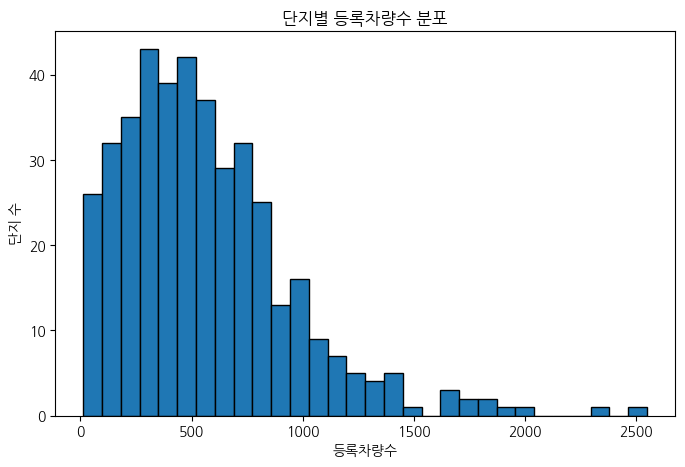

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(
    target_df['등록차량수'],
    bins=30,
    edgecolor='black'
)

plt.xlabel('등록차량수')
plt.ylabel('단지 수')
plt.title('단지별 등록차량수 분포')
plt.show()

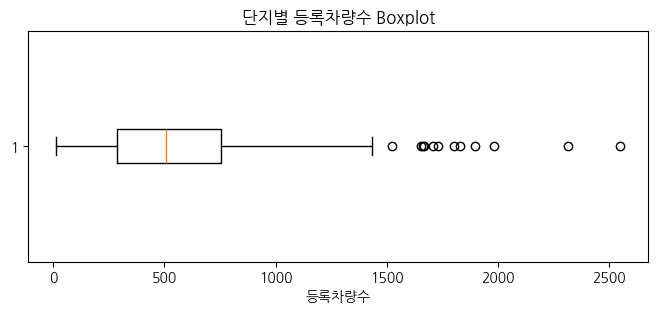

In [18]:
plt.figure(figsize=(8, 3))
plt.boxplot(
    target_df['등록차량수'],
    vert=False
)

plt.xlabel('등록차량수')
plt.title('단지별 등록차량수 Boxplot')
plt.show()

In [19]:
print(target_df['등록차량수'].describe())

print('\n왜도:',
      target_df['등록차량수'].skew())

count     411.000000
mean      564.318735
std       386.819089
min        13.000000
25%       286.000000
50%       505.000000
75%       753.000000
max      2550.000000
Name: 등록차량수, dtype: float64

왜도: 1.4044261539035015


In [20]:
target_df['세대당등록차량수'] = (
    target_df['등록차량수'] / target_df['총세대수']
)

target_df[['등록차량수', '세대당등록차량수']].describe()

,등록차량수,세대당등록차량수
count,411.000000,411.000000
mean,564.318735,0.814959
std,386.819089,0.368220
min,13.000000,0.047855
25%,286.000000,0.594356
50%,505.000000,0.819672
75%,753.000000,1.005914
max,2550.000000,2.289326


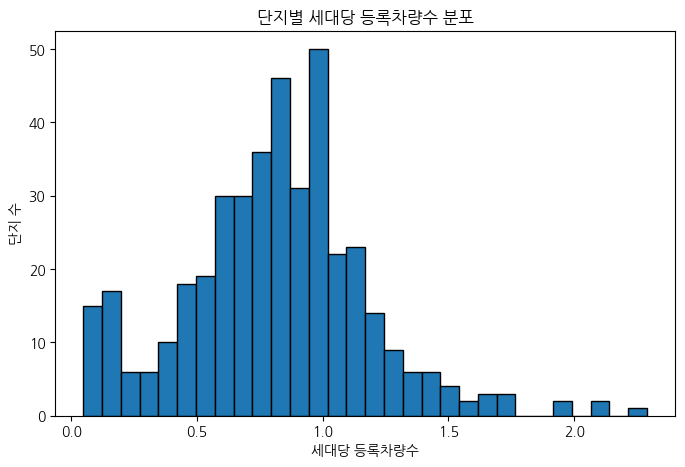

In [21]:
plt.figure(figsize=(8, 5))

plt.hist(
    target_df['세대당등록차량수'],
    bins=30,
    edgecolor='black'
)

plt.xlabel('세대당 등록차량수')
plt.ylabel('단지 수')
plt.title('단지별 세대당 등록차량수 분포')

plt.show()

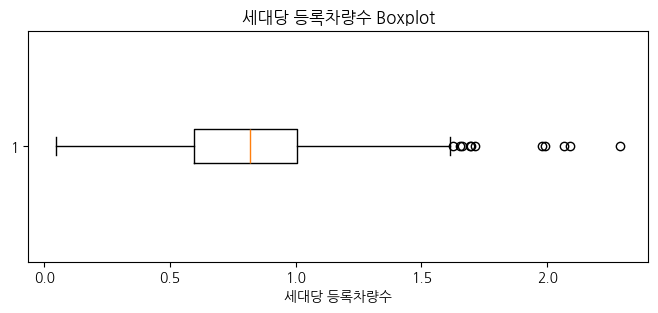

In [22]:
plt.figure(figsize=(8, 3))

plt.boxplot(
    target_df['세대당등록차량수'],
    vert=False
)

plt.xlabel('세대당 등록차량수')
plt.title('세대당 등록차량수 Boxplot')

plt.show()

**Target 분포 결과**

- 정상 Train 411개 단지의 등록차량수 중앙값은 505대이며, 평균은 약 564대로 나타났다.
- 등록차량수의 왜도는 약 1.40으로, 소수의 대규모 단지로 인해 오른쪽 꼬리가 긴 분포를 보인다.
- Boxplot에서도 등록차량수가 매우 높은 일부 단지가 확인되지만, 대규모 단지일 가능성이 있으므로 단순 이상치로 제거하지 않는다.
- 단지 규모의 영향을 제거하기 위해 `등록차량수 / 총세대수`로 세대당 등록차량수를 추가로 확인하였다.
- 세대당 등록차량수의 중앙값은 약 0.82대로, 대부분의 단지는 세대당 1대 내외의 차량을 보유하고 있으나 일부 단지는 1.5대 이상으로 높은 수준을 보인다.

## 2. 규모와 주차수요
단지 규모가 클수록 전체 등록차량수도 증가할 것으로 예상된다.
먼저 총세대수와 등록차량수의 관계를 확인한다.

In [23]:
from scipy.stats import spearmanr, pearsonr

pearson = pearsonr(
    target_df['총세대수'],
    target_df['등록차량수']
)

spearman = spearmanr(
    target_df['총세대수'],
    target_df['등록차량수']
)

print(f'Pearson 상관계수 : {pearson.statistic:.3f}')
print(f'Spearman 상관계수: {spearman.statistic:.3f}')

Pearson 상관계수 : 0.595
Spearman 상관계수: 0.641


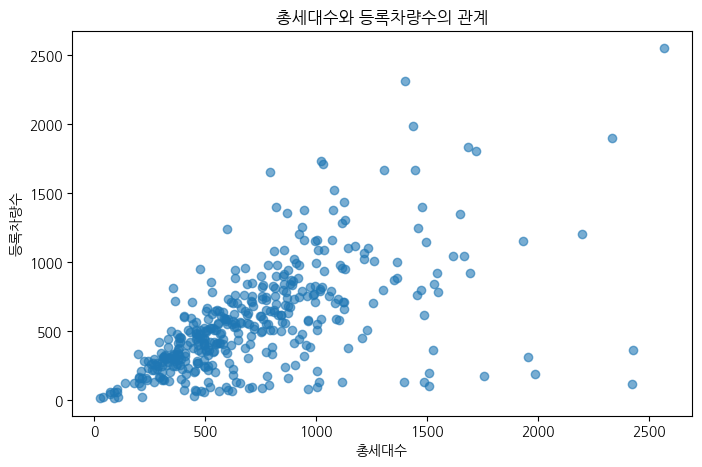

In [24]:
plt.figure(figsize=(8, 5))

plt.scatter(
    target_df['총세대수'],
    target_df['등록차량수'],
    alpha=0.6
)

plt.xlabel('총세대수')
plt.ylabel('등록차량수')
plt.title('총세대수와 등록차량수의 관계')

plt.show()

In [25]:
target_df['실거주세대수'] = (
    target_df['총세대수'] - target_df['공가수']
)

target_df['공가율'] = (
    target_df['공가수'] / target_df['총세대수']
)

Spearman 상관계수: 0.640


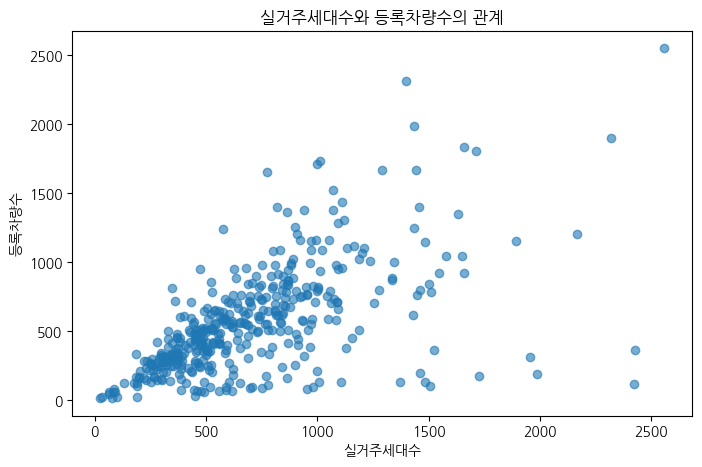

In [26]:
spearman = spearmanr(
    target_df['실거주세대수'],
    target_df['등록차량수']
)

print(f'Spearman 상관계수: {spearman.statistic:.3f}')

plt.figure(figsize=(8, 5))

plt.scatter(
    target_df['실거주세대수'],
    target_df['등록차량수'],
    alpha=0.6
)

plt.xlabel('실거주세대수')
plt.ylabel('등록차량수')
plt.title('실거주세대수와 등록차량수의 관계')

plt.show()

Spearman 상관계수: -0.030


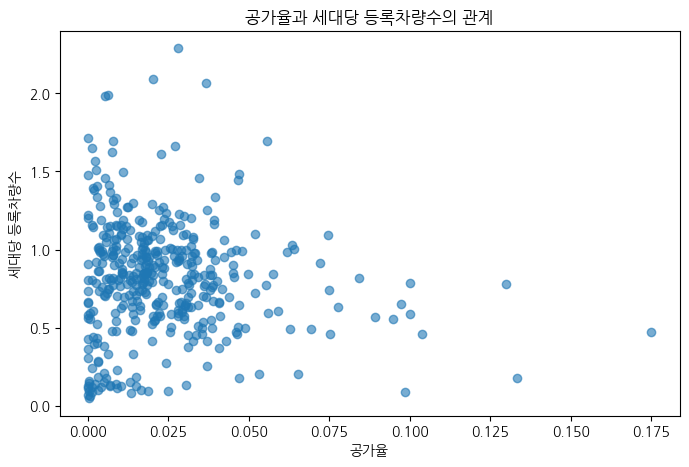

In [27]:
spearman = spearmanr(
    target_df['공가율'],
    target_df['세대당등록차량수']
)

print(f'Spearman 상관계수: {spearman.statistic:.3f}')

plt.figure(figsize=(8, 5))

plt.scatter(
    target_df['공가율'],
    target_df['세대당등록차량수'],
    alpha=0.6
)

plt.xlabel('공가율')
plt.ylabel('세대당 등록차량수')
plt.title('공가율과 세대당 등록차량수의 관계')

plt.show()

**규모와 주차수요 분석 결과**

- 총세대수와 등록차량수의 Spearman 상관계수는 0.641로, 단지 규모가 클수록 등록차량수가 증가하는 뚜렷한 양의 관계가 나타났다.
- Pearson 상관계수는 0.595로 나타나 전체적인 양의 선형 관계도 확인되었다.
- 다만 동일한 세대수에서도 등록차량수의 편차가 크게 나타나므로, 단지 규모 외의 주거 특성 및 입주계층 등의 요인도 차량수에 영향을 미치는 것으로 보인다.
- 공가수를 제외한 실거주세대수와 등록차량수의 Spearman 상관계수는 0.640으로 총세대수와 거의 동일하였다.
- 공가율과 세대당 등록차량수의 Spearman 상관계수는 -0.030으로, 두 변수 간 뚜렷한 단조 관계는 확인되지 않았다.

  ## 3. 주차 공급과 실제 주차수요

단지내주차면수는 단지 설계 과정에서 예상된 주차수요를 일부 반영한 변수일 수 있다.
단지내주차면수와 실제 등록차량수의 관계를 확인하고,
단지 규모를 제거한 세대당 지표에서도 관계가 유지되는지 살펴본다.

In [28]:
pearson = pearsonr(
    target_df['단지내주차면수'],
    target_df['등록차량수']
)

spearman = spearmanr(
    target_df['단지내주차면수'],
    target_df['등록차량수']
)

print(f'Pearson 상관계수 : {pearson.statistic:.3f}')
print(f'Spearman 상관계수: {spearman.statistic:.3f}')

Pearson 상관계수 : 0.848
Spearman 상관계수: 0.870


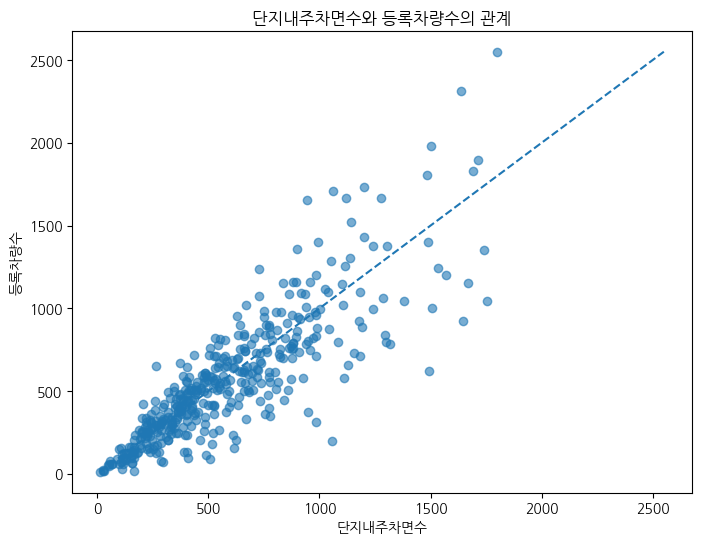

In [29]:
plt.figure(figsize=(8, 6))

plt.scatter(
    target_df['단지내주차면수'],
    target_df['등록차량수'],
    alpha=0.6
)

# y = x 기준선
min_val = min(
    target_df['단지내주차면수'].min(),
    target_df['등록차량수'].min()
)

max_val = max(
    target_df['단지내주차면수'].max(),
    target_df['등록차량수'].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel('단지내주차면수')
plt.ylabel('등록차량수')
plt.title('단지내주차면수와 등록차량수의 관계')

plt.show()

In [30]:
target_df['세대당주차면수'] = (
    target_df['단지내주차면수'] / target_df['총세대수']
)

spearman = spearmanr(
    target_df['세대당주차면수'],
    target_df['세대당등록차량수']
)

print(f'Spearman 상관계수: {spearman.statistic:.3f}')

Spearman 상관계수: 0.579


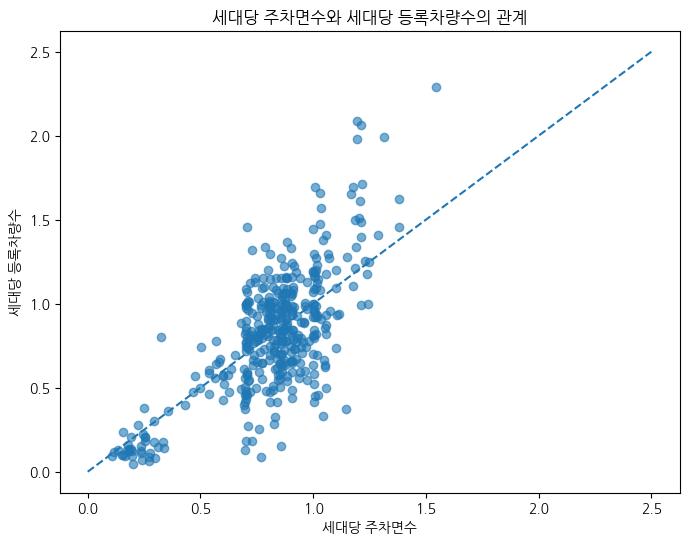

In [31]:
plt.figure(figsize=(8, 6))

plt.scatter(
    target_df['세대당주차면수'],
    target_df['세대당등록차량수'],
    alpha=0.6
)

plt.plot(
    [0, 2.5],
    [0, 2.5],
    linestyle='--'
)

plt.xlabel('세대당 주차면수')
plt.ylabel('세대당 등록차량수')
plt.title('세대당 주차면수와 세대당 등록차량수의 관계')

plt.show()

In [32]:
target_df['주차수급차이'] = (
    target_df['등록차량수'] - target_df['단지내주차면수']
)

target_df['주차수급차이'].describe()

,주차수급차이
count,411.000000
mean,-17.357664
std,207.852495
min,-874.000000
25%,-100.500000
50%,-1.000000
75%,80.000000
max,752.000000


**주차 공급과 실제 수요 분석 결과**

- 단지내주차면수와 등록차량수는 Pearson 0.848, Spearman 0.870으로 매우 강한 양의 관계를 보였다.
- 단지 규모의 영향을 제거한 세대당 주차면수와 세대당 등록차량수에서도 Spearman 0.579의 양의 관계가 나타났다.
- 따라서 주차면수와 등록차량수의 관계는 단순한 단지 규모 효과만으로 설명되지는 않는 것으로 보인다.
- `등록차량수 - 단지내주차면수`의 중앙값은 -1대로, 일반적인 단지에서는 주차면수와 등록차량수가 매우 유사한 수준이었다.
- 다만 단지별 편차가 크므로 일부 단지에서는 실제 등록차량수와 주차 공급 간 상당한 차이가 존재한다.
- 단지내주차면수는 설계 단계에서 예상 수요나 주차 기준을 반영했을 가능성이 있으므로, 높은 상관관계를 인과관계로 해석하지는 않는다.

## 4. 주거 특성 EDA

### 4-1. 평균 전용면적

In [33]:
# 주거 특성은 상가를 제외하고 아파트 행만 사용
apt_eda = eda_train[
    eda_train['임대건물구분'] == '아파트'
].copy()

In [34]:
def weighted_mean(group, col, weight='전용면적별세대수'):
    mask = group[col].notna() & (group[weight] > 0)

    if mask.sum() == 0:
        return np.nan

    return np.average(
        group.loc[mask, col],
        weights=group.loc[mask, weight]
    )

In [35]:
avg_area = (
    apt_eda.groupby('단지코드')
    .apply(lambda x: weighted_mean(x, '전용면적'))
    .rename('평균전용면적')
    .reset_index()
)

target_df = target_df.merge(
    avg_area,
    on='단지코드',
    how='left'
)

target_df[['평균전용면적', '등록차량수', '세대당등록차량수']].head()

/tmp/ipykernel_1863/353610556.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: weighted_mean(x, '전용면적'))


,평균전용면적,등록차량수,세대당등록차량수
0,42.175230,481.0,0.849823
1,39.504286,93.0,0.178503
2,53.441049,376.0,0.328671
3,45.952500,1665.0,1.272936
4,41.475843,708.0,0.710843


Spearman 상관계수: 0.430


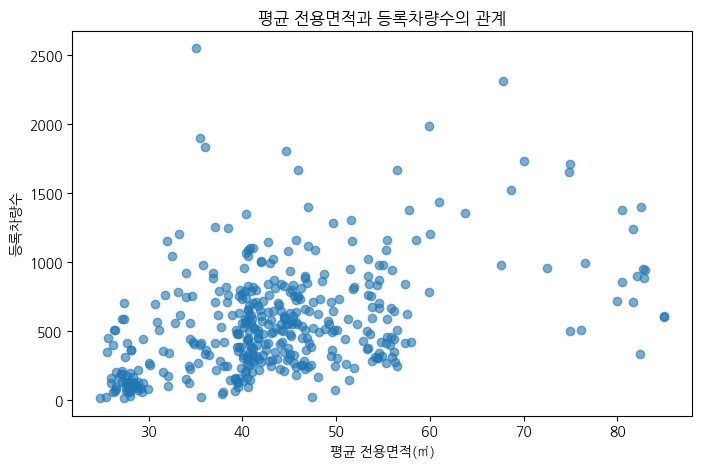

In [36]:
spearman = spearmanr(
    target_df['평균전용면적'],
    target_df['등록차량수'],
    nan_policy='omit'
)

print(f'Spearman 상관계수: {spearman.statistic:.3f}')

plt.figure(figsize=(8, 5))

plt.scatter(
    target_df['평균전용면적'],
    target_df['등록차량수'],
    alpha=0.6
)

plt.xlabel('평균 전용면적(㎡)')
plt.ylabel('등록차량수')
plt.title('평균 전용면적과 등록차량수의 관계')

plt.show()

Spearman 상관계수: 0.689


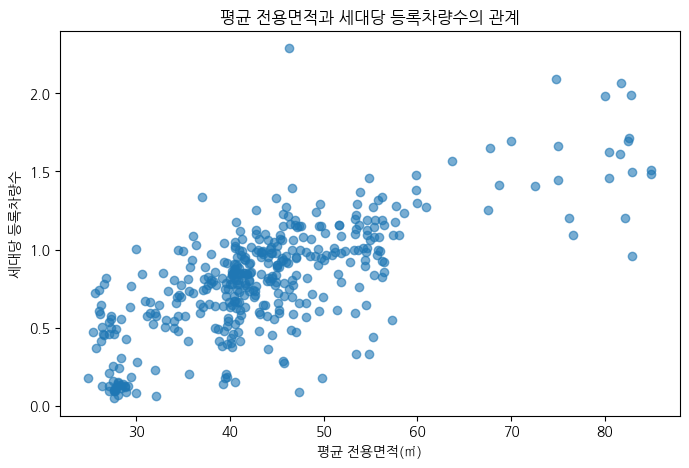

In [37]:
spearman = spearmanr(
    target_df['평균전용면적'],
    target_df['세대당등록차량수'],
    nan_policy='omit'
)

print(f'Spearman 상관계수: {spearman.statistic:.3f}')

plt.figure(figsize=(8, 5))

plt.scatter(
    target_df['평균전용면적'],
    target_df['세대당등록차량수'],
    alpha=0.6
)

plt.xlabel('평균 전용면적(㎡)')
plt.ylabel('세대당 등록차량수')
plt.title('평균 전용면적과 세대당 등록차량수의 관계')

plt.show()

**평균 전용면적 분석 결과**

- 평균 전용면적과 등록차량수의 Spearman 상관계수는 0.430으로 중간 정도의 양의 관계가 나타났다.
- 단지 규모의 영향을 제거한 평균 전용면적과 세대당 등록차량수의 Spearman 상관계수는 0.689로 더 강한 양의 관계를 보였다.
- 따라서 단순히 단지가 커서 차량수가 많은 것이 아니라, 상대적으로 넓은 평형이 많은 단지에서 세대당 차량 보유 수준이 높은 경향이 있는 것으로 보인다.
- 평균 전용면적은 가구 규모나 경제적 여건 등을 간접적으로 반영할 수 있으므로 주차수요 예측에 유용한 변수일 가능성이 있다.

### 4-2. 임대보증금 및 임대료

임대보증금과 임대료는 입주 가구의 경제적 특성을 간접적으로 반영할 수 있다.
단지별 단순 평균이 아니라 각 평형의 세대수를 고려한 가중평균을 사용하여
등록차량수 및 세대당 등록차량수와의 관계를 확인한다.

In [38]:
# 단지별 세대수 가중 평균 임대보증금 / 임대료

rent_features = (
    apt_eda.groupby('단지코드')
    .apply(
        lambda x: pd.Series({
            '평균임대보증금': weighted_mean(x, '임대보증금'),
            '평균임대료': weighted_mean(x, '임대료')
        })
    )
    .reset_index()
)

rent_features.head()

/tmp/ipykernel_1863/3890040039.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,단지코드,평균임대보증금,평균임대료
0,C1000,1.189725e+07,107462.279152
1,C1004,4.706095e+06,104719.523810
2,C1005,1.681811e+07,217779.440559
3,C1013,2.483090e+07,134092.217125
4,C1014,1.762135e+07,148407.389558


In [39]:
target_df = target_df.merge(
    rent_features,
    on='단지코드',
    how='left'
)

target_df[
    ['평균임대보증금', '평균임대료',
     '등록차량수', '세대당등록차량수']
].head()

,평균임대보증금,평균임대료,등록차량수,세대당등록차량수
0,1.189725e+07,107462.279152,481.0,0.849823
1,4.706095e+06,104719.523810,93.0,0.178503
2,1.681811e+07,217779.440559,376.0,0.328671
3,2.483090e+07,134092.217125,1665.0,1.272936
4,1.762135e+07,148407.389558,708.0,0.710843


In [40]:
target_df[
    ['평균임대보증금', '평균임대료']
].isna().sum()

,0
평균임대보증금,1
평균임대료,1


Spearman 상관계수: 0.484


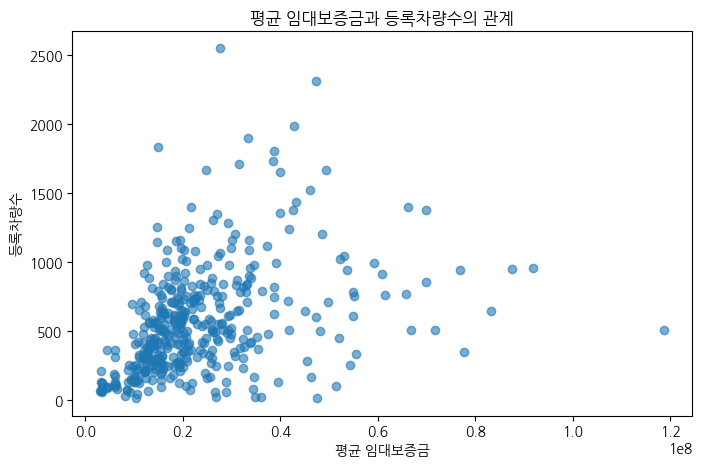

In [41]:
tmp = target_df[['평균임대보증금', '등록차량수']].dropna()

spearman = spearmanr(
    tmp['평균임대보증금'],
    tmp['등록차량수']
)

print(f'Spearman 상관계수: {spearman.statistic:.3f}')

plt.figure(figsize=(8, 5))

plt.scatter(
    tmp['평균임대보증금'],
    tmp['등록차량수'],
    alpha=0.6
)

plt.xlabel('평균 임대보증금')
plt.ylabel('등록차량수')
plt.title('평균 임대보증금과 등록차량수의 관계')

plt.show()

Spearman 상관계수: 0.465


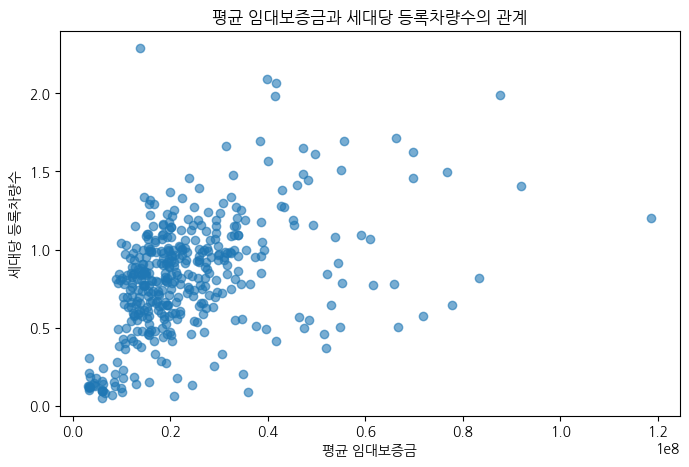

In [42]:
tmp = target_df[
    ['평균임대보증금', '세대당등록차량수']
].dropna()

spearman = spearmanr(
    tmp['평균임대보증금'],
    tmp['세대당등록차량수']
)

print(f'Spearman 상관계수: {spearman.statistic:.3f}')

plt.figure(figsize=(8, 5))

plt.scatter(
    tmp['평균임대보증금'],
    tmp['세대당등록차량수'],
    alpha=0.6
)

plt.xlabel('평균 임대보증금')
plt.ylabel('세대당 등록차량수')
plt.title('평균 임대보증금과 세대당 등록차량수의 관계')

plt.show()

Spearman 상관계수: 0.495


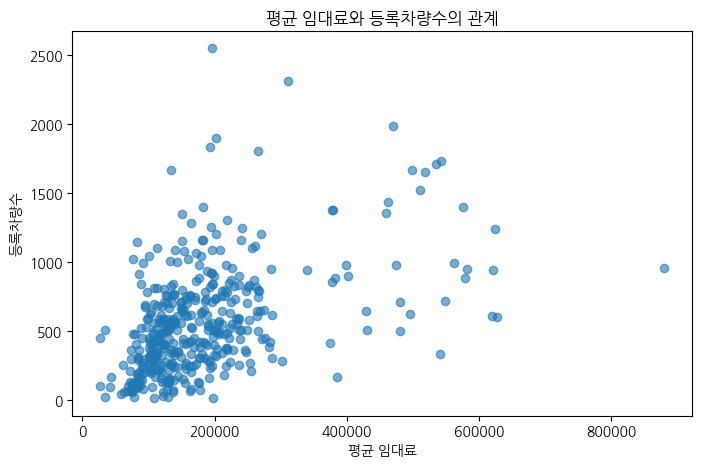

In [43]:
tmp = target_df[
    ['평균임대료', '등록차량수']
].dropna()

spearman = spearmanr(
    tmp['평균임대료'],
    tmp['등록차량수']
)

print(f'Spearman 상관계수: {spearman.statistic:.3f}')

plt.figure(figsize=(8, 5))

plt.scatter(
    tmp['평균임대료'],
    tmp['등록차량수'],
    alpha=0.6
)

plt.xlabel('평균 임대료')
plt.ylabel('등록차량수')
plt.title('평균 임대료와 등록차량수의 관계')

plt.show()

Spearman 상관계수: 0.492


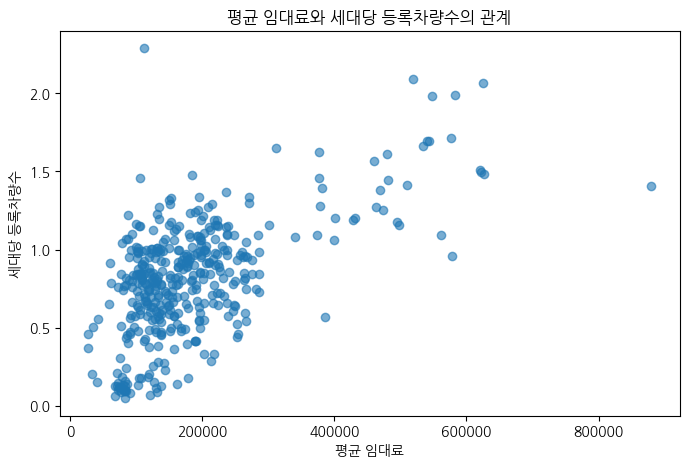

In [44]:
tmp = target_df[
    ['평균임대료', '세대당등록차량수']
].dropna()

spearman = spearmanr(
    tmp['평균임대료'],
    tmp['세대당등록차량수']
)

print(f'Spearman 상관계수: {spearman.statistic:.3f}')

plt.figure(figsize=(8, 5))

plt.scatter(
    tmp['평균임대료'],
    tmp['세대당등록차량수'],
    alpha=0.6
)

plt.xlabel('평균 임대료')
plt.ylabel('세대당 등록차량수')
plt.title('평균 임대료와 세대당 등록차량수의 관계')

plt.show()

**임대조건 분석 결과**

- 평균 임대보증금과 등록차량수의 Spearman 상관계수는 0.484,
  세대당 등록차량수와의 상관계수는 0.465로 나타났다.
- 평균 임대료와 등록차량수의 Spearman 상관계수는 0.495,
  세대당 등록차량수와의 상관계수는 0.492로 나타났다.
- 임대보증금과 임대료 모두 차량 보유 수준과 중간 정도의 양의 관계를 보였다.
- 단지 규모를 제거한 이후에도 관계의 크기가 크게 변하지 않아,
  임대조건이 단지 규모와 별개로 차량 보유 수준과 관련된 정보를 포함하고 있을 가능성이 있다.
- 다만 임대보증금과 임대료는 전용면적이나 공급유형 등의 주거 특성과 함께 결정될 수 있으므로,
  이를 직접적인 인과관계로 해석하지 않는다.

## 5. 범주형/도메인 분석

### 5-1. 공급유형별 세대당 차량수

공급유형은 입주 대상 및 정책 목적에 따라 가구의 연령, 소득, 가구 구성 등이 달라질 수 있으므로
차량 보유 수준에도 차이가 나타날 가능성이 있다.

한 단지에 여러 공급유형이 존재할 수 있으므로,
각 단지에서 가장 많은 세대를 차지하는 공급유형을 주공급유형으로 정의하여 비교한다.

In [47]:
# 단지 × 공급유형별 세대수 계산
supply_households = (
    apt_eda
    .groupby(['단지코드', '공급유형'])['전용면적별세대수']
    .sum()
    .reset_index()
)

# 각 단지에서 세대수가 가장 많은 공급유형
main_supply = (
    supply_households
    .sort_values(['단지코드', '전용면적별세대수'], ascending=[True, False])
    .drop_duplicates('단지코드')
    [['단지코드', '공급유형']]
    .rename(columns={'공급유형': '주공급유형'})
)

target_df = target_df.merge(
    main_supply,
    on='단지코드',
    how='left'
)

target_df['주공급유형'].value_counts()

,count
주공급유형,
국민임대,305
영구임대,33
공공임대(10년),32
행복주택,29
공공임대(50년),9
공공임대(분납),1
공공분양,1
공공임대(5년),1


In [48]:
supply_summary = (
    target_df
    .groupby('주공급유형')['세대당등록차량수']
    .agg(['count', 'mean', 'median'])
    .sort_values('mean', ascending=False)
)

supply_summary

,count,mean,median
주공급유형,,,
공공분양,1,1.652391,1.652391
공공임대(10년),32,1.462302,1.451398
공공임대(5년),1,1.394654,1.394654
공공임대(분납),1,1.200472,1.200472
국민임대,305,0.846621,0.847423
행복주택,29,0.561628,0.555932
공공임대(50년),9,0.524099,0.476309
영구임대,33,0.141929,0.127345


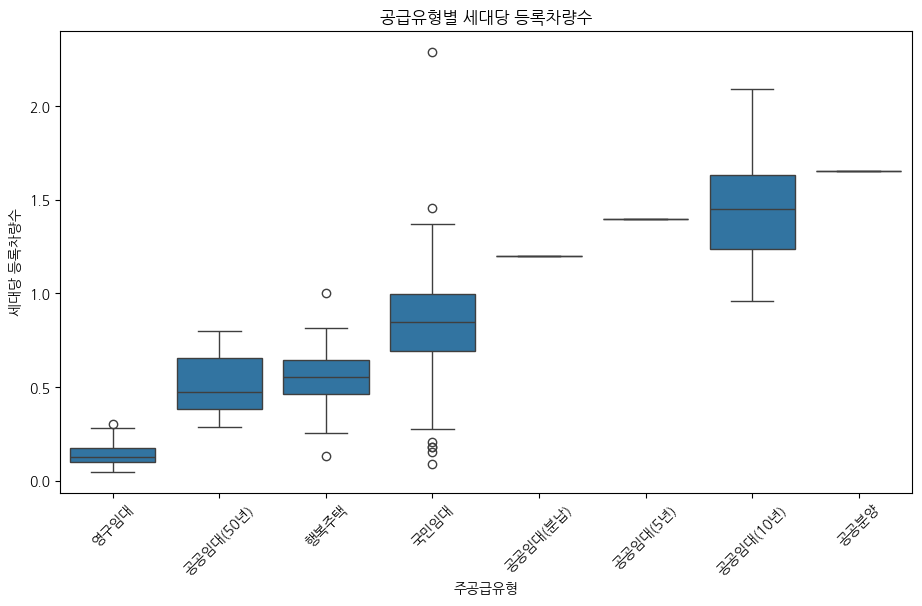

In [49]:
import seaborn as sns

plt.figure(figsize=(11, 6))

order = (
    target_df.groupby('주공급유형')['세대당등록차량수']
    .median()
    .sort_values()
    .index
)

sns.boxplot(
    data=target_df,
    x='주공급유형',
    y='세대당등록차량수',
    order=order
)

plt.xticks(rotation=45)
plt.xlabel('주공급유형')
plt.ylabel('세대당 등록차량수')
plt.title('공급유형별 세대당 등록차량수')

plt.show()

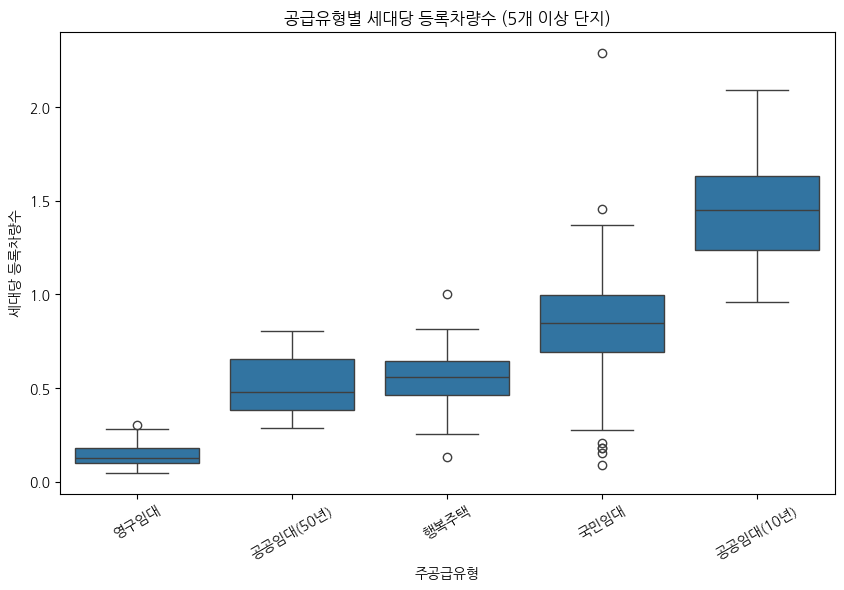

In [50]:
# 비교 가능한 수준의 표본이 있는 공급유형만 시각화
supply_counts = target_df['주공급유형'].value_counts()
valid_supply = supply_counts[supply_counts >= 5].index

plot_df = target_df[
    target_df['주공급유형'].isin(valid_supply)
].copy()

order = (
    plot_df.groupby('주공급유형')['세대당등록차량수']
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=plot_df,
    x='주공급유형',
    y='세대당등록차량수',
    order=order
)

plt.xlabel('주공급유형')
plt.ylabel('세대당 등록차량수')
plt.title('공급유형별 세대당 등록차량수 (5개 이상 단지)')
plt.xticks(rotation=30)

plt.show()

**공급유형별 분석 결과**

- 주공급유형에 따라 세대당 등록차량수에 뚜렷한 차이가 나타났다.
- 충분한 표본이 존재하는 유형 중 공공임대(10년)의 세대당 등록차량수 평균은 약 1.46대로 가장 높았으며,
  국민임대는 약 0.85대, 행복주택은 약 0.56대, 영구임대는 약 0.14대로 나타났다.
- 특히 영구임대와 공공임대(10년) 사이의 차이가 크게 나타나,
  공급유형이 차량 보유 수준을 설명하는 중요한 범주형 변수일 가능성이 있다.
- 공급유형은 입주 대상의 소득, 연령, 가구 구성 및 주택 면적 등의 차이를 함께 반영할 수 있으므로
  공급유형 자체의 직접적인 인과효과로 해석하지 않는다.
- 공공분양, 공공임대(5년), 공공임대(분납)은 주공급유형에 해당하는 단지가 각각 1개뿐이므로
  해당 평균값은 대표적인 특성으로 해석하기 어렵다.

### 5-2. 지역별 세대당 차량수

In [51]:
region_df = (
    eda_train
    .groupby('단지코드', as_index=False)
    .agg(지역=('지역', 'first'))
)

target_df = target_df.merge(
    region_df,
    on='단지코드',
    how='left'
)

In [52]:
region_summary = (
    target_df
    .groupby('지역')['세대당등록차량수']
    .agg(['count', 'mean', 'median'])
    .sort_values('mean', ascending=False)
)

region_summary

,count,mean,median
지역,,,
세종특별자치시,3,1.292665,1.378999
대구광역시,18,0.994614,0.989018
경상북도,21,0.981074,0.976783
광주광역시,24,0.966611,0.998339
경기도,84,0.921342,0.933540
서울특별시,6,0.914481,0.781275
충청북도,30,0.914343,0.832393
전라남도,24,0.818780,0.769172
전라북도,21,0.810872,0.749226


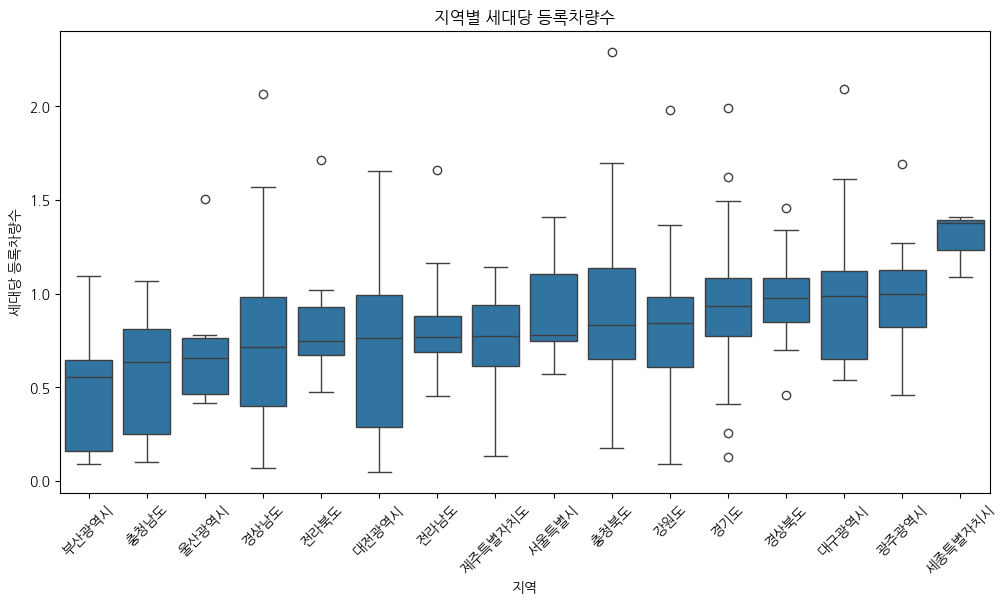

In [53]:
plt.figure(figsize=(12, 6))

order = (
    target_df.groupby('지역')['세대당등록차량수']
    .median()
    .sort_values()
    .index
)

sns.boxplot(
    data=target_df,
    x='지역',
    y='세대당등록차량수',
    order=order
)

plt.xlabel('지역')
plt.ylabel('세대당 등록차량수')
plt.title('지역별 세대당 등록차량수')
plt.xticks(rotation=45)

plt.show()

**지역별 분석 결과**

- 지역별 세대당 등록차량수에 차이가 나타났다.
- 평균 기준으로 세종특별자치시, 대구광역시, 경상북도, 광주광역시 등이 상대적으로 높았으며,
  부산광역시와 충청남도 등은 상대적으로 낮은 수준을 보였다.
- 그러나 세종특별자치시(3개), 서울특별시(6개), 울산광역시(7개) 등 일부 지역은
  단지 수가 적으므로 평균값을 해당 지역의 일반적인 특성으로 해석하는 데 주의가 필요하다.
- 각 지역 내부에서도 세대당 등록차량수의 분산이 크게 나타나,
  지역만으로 주차수요를 설명하기보다는 공급유형, 전용면적, 임대조건 등의
  단지 특성과 함께 고려할 필요가 있다.
- 따라서 `지역`은 차량 보유 수준에 관한 정보를 포함할 가능성이 있으나,
  지역 자체의 직접적인 영향으로 해석하지 않는다.

### 5-3. 자격유형별 세대당 차량수

자격유형은 입주 대상의 소득, 가구 구성 등과 관련된 변수이므로
차량 보유 수준에도 차이가 나타날 가능성이 있다.

한 단지에 여러 자격유형이 존재할 수 있으므로,
각 단지에서 가장 많은 세대가 해당하는 자격유형을 주자격유형으로 정의하여
세대당 등록차량수를 비교한다.

In [54]:
# 단지 × 자격유형별 세대수
qual_households = (
    apt_eda
    .groupby(['단지코드', '자격유형'])['전용면적별세대수']
    .sum()
    .reset_index()
)

# 단지에서 가장 많은 세대가 해당하는 자격유형
main_qual = (
    qual_households
    .sort_values(
        ['단지코드', '전용면적별세대수'],
        ascending=[True, False]
    )
    .drop_duplicates('단지코드')
    [['단지코드', '자격유형']]
    .rename(columns={'자격유형': '주자격유형'})
)

target_df = target_df.merge(
    main_qual,
    on='단지코드',
    how='left'
)

target_df['주자격유형'].value_counts()

,count
주자격유형,
A,312
C,32
H,26
J,16
E,6
K,5
L,5
B,3
N,3


In [55]:
qual_summary = (
    target_df
    .groupby('주자격유형')['세대당등록차량수']
    .agg(['count', 'mean', 'median'])
    .sort_values('mean', ascending=False)
)

qual_summary

,count,mean,median
주자격유형,,,
D,1,1.652391,1.652391
A,312,0.913727,0.898422
B,3,0.891006,0.966887
H,26,0.763265,0.772851
E,6,0.696963,0.743608
L,5,0.605895,0.500000
J,16,0.573894,0.597956
G,1,0.542430,0.542430
K,5,0.522282,0.502988


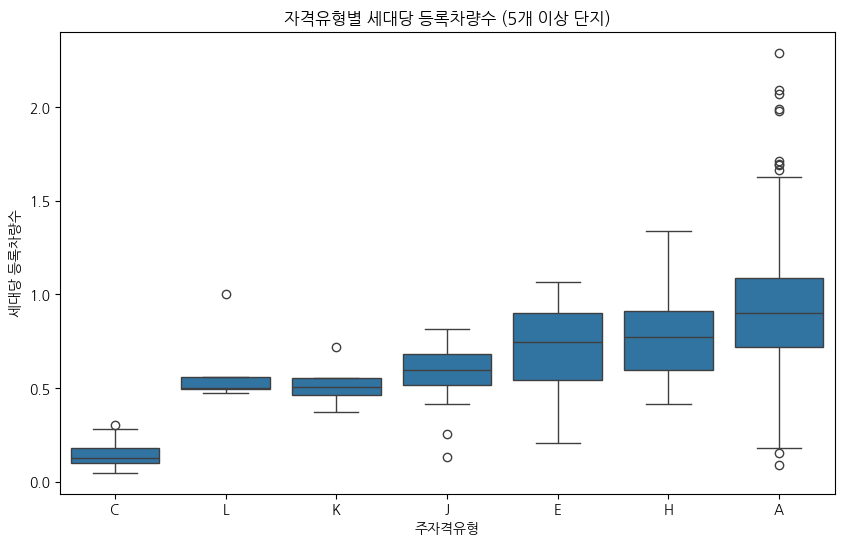

In [56]:
qual_counts = target_df['주자격유형'].value_counts()
valid_qual = qual_counts[qual_counts >= 5].index

plot_df = target_df[
    target_df['주자격유형'].isin(valid_qual)
].copy()

order = (
    plot_df
    .groupby('주자격유형')['세대당등록차량수']
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=plot_df,
    x='주자격유형',
    y='세대당등록차량수',
    order=order
)

plt.xlabel('주자격유형')
plt.ylabel('세대당 등록차량수')
plt.title('자격유형별 세대당 등록차량수 (5개 이상 단지)')

plt.show()

**자격유형별 분석 결과**

- 주자격유형에 따라 세대당 등록차량수에 뚜렷한 차이가 나타났다.
- 가장 많은 단지를 차지하는 A 유형의 세대당 등록차량수 평균은 약 0.91대였으며,
  C 유형은 약 0.14대로 매우 낮은 수준을 보였다.
- H, E, J 등의 유형에서도 서로 다른 차량 보유 수준이 나타나,
  자격유형이 주차수요를 설명하는 유용한 범주형 정보일 가능성이 있다.
- 다만 A 유형에 단지가 집중되어 있으며, 일부 자격유형은 표본 수가 매우 적으므로
  소수 유형의 평균값을 일반적인 특성으로 해석하는 데 주의가 필요하다.
- 현재 데이터에서는 A, C 등의 코드가 의미하는 세부 자격 조건이 직접 제공되지 않으므로,
  코드별 차이는 확인하되 그 원인을 특정 입주계층의 특성으로 단정하지 않는다.

### 5-4. 지역 인구 연령구조와 보유 차량수

`age_gender_info.csv`는 단지별 정보가 아니라 지역별 인구구조 정보이므로,
단지 단위에서 동일한 지역 값을 반복하여 분석하지 않고 지역 단위로 집계하여 분석한다.

각 지역의 연령대별 남녀 비율을 합산하고,
지역별 세대당 등록차량수의 중앙값 및 평균과의 관계를 확인한다.

In [57]:
age_eda = age.copy()

for decade in ['10대미만', '10대', '20대', '30대', '40대',
               '50대', '60대', '70대', '80대', '90대', '100대']:

    age_eda[f'{decade}비율'] = (
        age_eda[f'{decade}(여자)'] +
        age_eda[f'{decade}(남자)']
    )

In [58]:
age_eda['20대비율'] = age_eda['20대비율']

age_eda['30~50대비율'] = (
    age_eda['30대비율'] +
    age_eda['40대비율'] +
    age_eda['50대비율']
)

age_eda['20~50대비율'] = (
    age_eda['20대비율'] +
    age_eda['30대비율'] +
    age_eda['40대비율'] +
    age_eda['50대비율']
)

age_eda['60대이상비율'] = (
    age_eda['60대비율'] +
    age_eda['70대비율'] +
    age_eda['80대비율'] +
    age_eda['90대비율'] +
    age_eda['100대비율']
)

In [59]:
age_features = age_eda[
    [
        '지역',
        '20대비율',
        '30~50대비율',
        '20~50대비율',
        '60대이상비율'
    ]
].copy()

age_features.head()

,지역,20대비율,30~50대비율,20~50대비율,60대이상비율
0,경상북도,0.127956,0.418573,0.546529,0.272413
1,경상남도,0.135538,0.418098,0.553635,0.283237
2,대전광역시,0.125081,0.432663,0.557744,0.301685
3,경기도,0.118378,0.444801,0.563179,0.252748
4,전라북도,0.136585,0.398062,0.534647,0.288433


In [60]:
region_target = (
    target_df
    .groupby('지역')
    .agg(
        단지수=('단지코드', 'count'),
        평균세대당등록차량수=('세대당등록차량수', 'mean'),
        중앙값세대당등록차량수=('세대당등록차량수', 'median')
    )
    .reset_index()
)

region_target

,지역,단지수,평균세대당등록차량수,중앙값세대당등록차량수
0,강원도,37,0.807988,0.841711
1,경기도,84,0.921342,0.933540
2,경상남도,53,0.708794,0.713092
3,경상북도,21,0.981074,0.976783
4,광주광역시,24,0.966611,0.998339
5,대구광역시,18,0.994614,0.989018
6,대전광역시,25,0.674339,0.762500
7,부산광역시,25,0.478744,0.552894
8,서울특별시,6,0.914481,0.781275
9,세종특별자치시,3,1.292665,1.378999


In [61]:
region_age = region_target.merge(
    age_features,
    on='지역',
    how='left'
)

region_age

,지역,단지수,평균세대당등록차량수,중앙값세대당등록차량수,20대비율,30~50대비율,20~50대비율,60대이상비율
0,강원도,37,0.807988,0.841711,0.123531,0.417789,0.541319,0.295113
1,경기도,84,0.921342,0.933540,0.118378,0.444801,0.563179,0.252748
2,경상남도,53,0.708794,0.713092,0.135538,0.418098,0.553635,0.283237
3,경상북도,21,0.981074,0.976783,0.127956,0.418573,0.546529,0.272413
4,광주광역시,24,0.966611,0.998339,0.131960,0.437860,0.569820,0.263516
5,대구광역시,18,0.994614,0.989018,0.130810,0.436390,0.567200,0.311415
6,대전광역시,25,0.674339,0.762500,0.125081,0.432663,0.557744,0.301685
7,부산광역시,25,0.478744,0.552894,0.111030,0.370390,0.481420,0.405437
8,서울특별시,6,0.914481,0.781275,0.109495,0.364385,0.473879,0.443840
9,세종특별자치시,3,1.292665,1.378999,0.144116,0.484350,0.628466,0.194554


In [62]:
from scipy.stats import spearmanr

age_cols = [
    '20대비율',
    '30~50대비율',
    '20~50대비율',
    '60대이상비율'
]

print('[지역별 세대당 등록차량수 중앙값 기준]')

for col in age_cols:
    tmp = region_age[
        [col, '중앙값세대당등록차량수']
    ].dropna()

    corr = spearmanr(
        tmp[col],
        tmp['중앙값세대당등록차량수']
    )

    print(f'{col}: {corr.statistic:.3f}')

[지역별 세대당 등록차량수 중앙값 기준]
20대비율: -0.082
30~50대비율: 0.591
20~50대비율: 0.447
60대이상비율: -0.247


In [63]:
print('[지역별 세대당 등록차량수 평균 기준]')

for col in age_cols:
    tmp = region_age[
        [col, '평균세대당등록차량수']
    ].dropna()

    corr = spearmanr(
        tmp[col],
        tmp['평균세대당등록차량수']
    )

    print(f'{col}: {corr.statistic:.3f}')

[지역별 세대당 등록차량수 평균 기준]
20대비율: 0.000
30~50대비율: 0.482
20~50대비율: 0.353
60대이상비율: -0.232


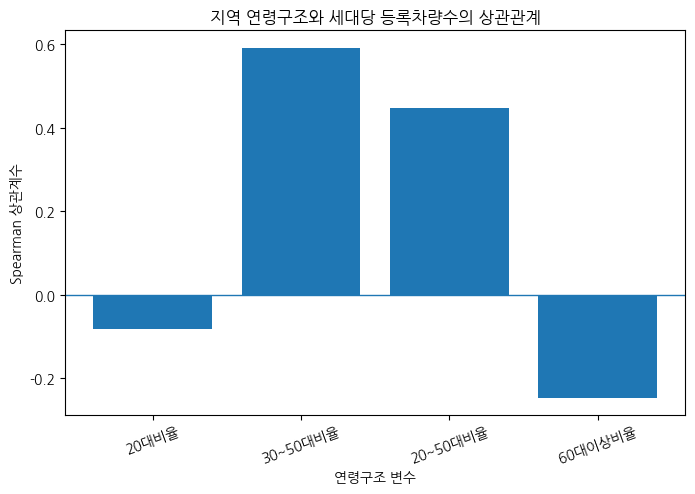

In [64]:
correlations = []
for col in age_cols:
    tmp = region_age[[col, '중앙값세대당등록차량수']].dropna()
    corr = spearmanr(tmp[col], tmp['중앙값세대당등록차량수'])
    correlations.append({'연령특성': col, 'Spearman상관계수': corr.statistic})

age_corr_df = pd.DataFrame(correlations)

plt.figure(figsize=(8, 5))

plt.bar(
    age_corr_df['연령특성'],
    age_corr_df['Spearman상관계수']
)

plt.axhline(0, linewidth=1)
plt.ylabel('Spearman 상관계수')
plt.xlabel('연령구조 변수')
plt.title('지역 연령구조와 세대당 등록차량수의 상관관계')
plt.xticks(rotation=20)

plt.show()

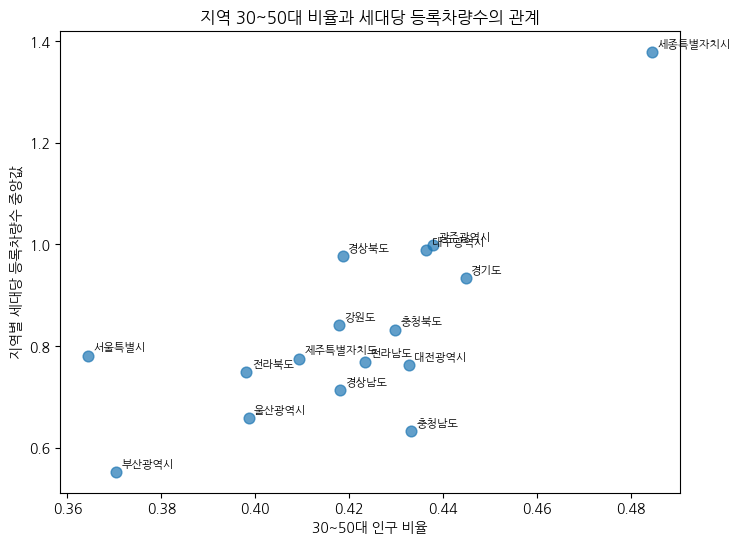

In [65]:
plt.figure(figsize=(8, 6))

plt.scatter(
    region_age['30~50대비율'],
    region_age['중앙값세대당등록차량수'],
    s=60,
    alpha=0.7
)

for _, row in region_age.iterrows():
    plt.annotate(
        row['지역'],
        (
            row['30~50대비율'],
            row['중앙값세대당등록차량수']
        ),
        fontsize=8,
        xytext=(4, 4),
        textcoords='offset points'
    )

plt.xlabel('30~50대 인구 비율')
plt.ylabel('지역별 세대당 등록차량수 중앙값')
plt.title('지역 30~50대 비율과 세대당 등록차량수의 관계')

plt.show()

**지역 연령구조 분석 결과**

- 지역 단위 인구구조와 세대당 등록차량수의 관계를 분석한 결과,
  `30~50대 인구 비율`이 가장 뚜렷한 양의 관계를 보였다.
- 지역별 세대당 등록차량수 중앙과 평균을 기준으로 한 Spearman 상관계수는 30-50대 비율이 가장 높았다..
- 산점도에서도 30-50대 인구 비율이 높은 지역일수록
  세대당 등록차량수 중앙값이 대체로 높은 경향을 확인할 수 있다.
  특히 세종특별자치시는 30-50대 비율과 세대당 등록차량수가 모두 높은 지역으로 나타났다.
- 다만 동일한 30-50대 비율에서도 지역별 차량 보유 수준에 차이가 존재하며,
  서울특별시·부산광역시·충청남도 등 일부 지역은 전체적인 경향에서 벗어나는 모습도 나타난다.
  따라서 연령구조만으로 지역별 차량 보유 수준을 설명하기는 어렵고,
  공급유형, 주택 면적, 임대조건 등 다른 지역·단지 특성이 함께 작용하는 것으로 보인다.
- 따라서 지역 인구구조를 피처로 활용할 경우 기존의 `20~50대 비율`보다
  `30~50대 비율`을 우선적인 후보 변수로 고려할 수 있다.

## 6. Train-Test Distribution Shift

Train과 Test의 입력 변수 분포가 크게 다를 경우,
Train에서 학습한 관계가 Test에 동일하게 적용되지 않을 수 있다.

따라서 단지 단위로 데이터를 집계한 뒤,
주요 수치형 변수와 지역 구성의 분포를 비교한다.

### 6-1. 단지 단위 Train/Test 데이터 생성

In [66]:
# Distribution Shift 분석용 Test
eda_test_eval = eda_test[
    ~eda_test['단지코드'].isin(error_test)
].copy()

print('Train 단지 수:', eda_train['단지코드'].nunique())
print('Test 단지 수 :', eda_test_eval['단지코드'].nunique())

Train 단지 수: 411
Test 단지 수 : 147


In [67]:
# 교통 관련 컬럼명 다시 통일
RENAME = {
    '도보 10분거리 내 지하철역 수(환승노선 수 반영)': '지하철역수',
    '도보 10분거리 내 버스정류장 수': '버스정류장수'
}

eda_train = eda_train.rename(columns=RENAME)
eda_test_eval = eda_test_eval.rename(columns=RENAME)

print(eda_train.columns.tolist())

['단지코드', '총세대수', '임대건물구분', '지역', '공급유형', '전용면적', '전용면적별세대수', '공가수', '자격유형', '임대보증금', '임대료', '지하철역수', '버스정류장수', '단지내주차면수', '등록차량수']


In [68]:
def make_complex_base(df):
    base = (
        df.groupby('단지코드', as_index=False)
        .agg(
            지역=('지역', 'first'),
            총세대수=('총세대수', 'first'),
            공가수=('공가수', 'first'),
            지하철역수=('지하철역수', 'first'),
            버스정류장수=('버스정류장수', 'first'),
            단지내주차면수=('단지내주차면수', 'first')
        )
    )

    base['공가율'] = base['공가수'] / base['총세대수']

    base['세대당주차면수'] = (
        base['단지내주차면수'] / base['총세대수']
    )

    return base


train_dist = make_complex_base(eda_train)
test_dist = make_complex_base(eda_test_eval)

print(train_dist.shape)
print(test_dist.shape)

(411, 9)
(147, 9)


### 6-2. 주요 변수의 기초통계 비교

In [69]:
compare_cols = [
    '총세대수',
    '공가수',
    '공가율',
    '단지내주차면수',
    '세대당주차면수',
    '지하철역수',
    '버스정류장수'
]

dist_summary = pd.DataFrame({
    'Train 평균': train_dist[compare_cols].mean(),
    'Test 평균': test_dist[compare_cols].mean(),
    'Train 중앙값': train_dist[compare_cols].median(),
    'Test 중앙값': test_dist[compare_cols].median()
})

dist_summary.round(3)

,Train 평균,Test 평균,Train 중앙값,Test 중앙값
총세대수,722.348,694.714,632.000,602.000
공가수,13.416,15.333,13.000,15.000
공가율,0.023,0.027,0.018,0.021
단지내주차면수,581.676,558.388,515.000,499.000
세대당주차면수,0.814,0.815,0.846,0.844
지하철역수,0.130,0.098,0.000,0.000
버스정류장수,3.708,4.531,3.000,3.000


### 6-3. Train/Test 분포를 그래프로 비교

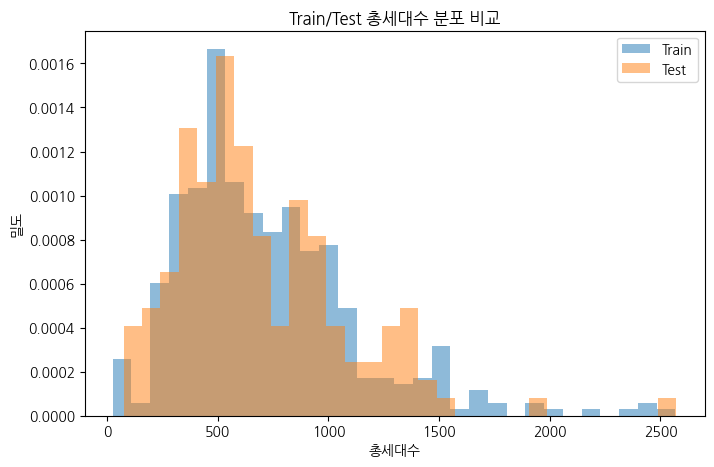

In [70]:
plt.figure(figsize=(8, 5))

plt.hist(
    train_dist['총세대수'],
    bins=30,
    alpha=0.5,
    density=True,
    label='Train'
)

plt.hist(
    test_dist['총세대수'],
    bins=30,
    alpha=0.5,
    density=True,
    label='Test'
)

plt.xlabel('총세대수')
plt.ylabel('밀도')
plt.title('Train/Test 총세대수 분포 비교')
plt.legend()

plt.show()

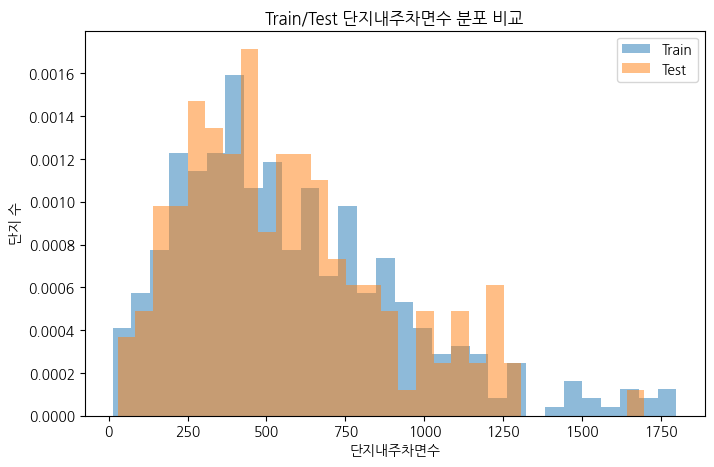

In [71]:
plt.figure(figsize=(8, 5))

plt.hist(
    train_dist['단지내주차면수'],
    bins=30,
    alpha=0.5,
    density=True,
    label='Train'
)

plt.hist(
    test_dist['단지내주차면수'],
    bins=30,
    alpha=0.5,
    density=True,
    label='Test'
)

plt.xlabel('단지내주차면수')
plt.ylabel('단지 수')
plt.title('Train/Test 단지내주차면수 분포 비교')
plt.legend()

plt.show()

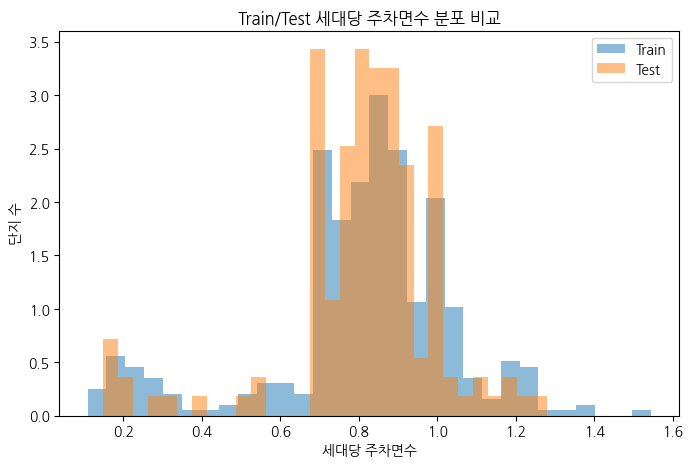

In [72]:
plt.figure(figsize=(8, 5))

plt.hist(
    train_dist['세대당주차면수'],
    bins=30,
    alpha=0.5,
    density=True,
    label='Train'
)

plt.hist(
    test_dist['세대당주차면수'],
    bins=30,
    alpha=0.5,
    density=True,
    label='Test'
)

plt.xlabel('세대당 주차면수')
plt.ylabel('단지 수')
plt.title('Train/Test 세대당 주차면수 분포 비교')
plt.legend()

plt.show()

**주요 수치형 변수의 Train/Test 비교**

- Train과 Test의 주요 단지 특성은 전반적으로 유사한 분포를 보였다.
- 세대당 주차면수는 Train 0.814, Test 0.815로 거의 동일하여
  단지 규모를 보정한 주차 공급 수준에서는 두 데이터 간 차이가 거의 나타나지 않았다.공가율 역시 Train 0.023, Test 0.027로 큰 차이가 없었다.
- 교통 관련 변수에서는 버스정류장수 평균이 Train 3.71, Test 4.53으로
  다른 주요 변수에 비해 다소 차이를 보였다.
- 따라서 핵심 규모·주차 관련 변수에서 극단적인 분포 차이는 확인되지 않았으나,
  일부 변수와 지역 구성에서는 추가적인 Train/Test 차이를 확인할 필요가 있다.

### 6-4. Train/Test 지역 구성 비교

수치형 변수의 분포가 유사하더라도 Train과 Test에 포함된 지역의 비중이 다르면
지역 특성을 활용하는 모델의 일반화 성능에 영향을 줄 수 있다.

따라서 단지 수 기준으로 Train과 Test의 지역별 구성 비율을 비교한다.

In [73]:
train_region = (
    train_dist['지역']
    .value_counts(normalize=True)
    .rename('Train 비율')
)

test_region = (
    test_dist['지역']
    .value_counts(normalize=True)
    .rename('Test 비율')
)

region_compare = pd.concat(
    [train_region, test_region],
    axis=1
).fillna(0)

region_compare['차이(Test-Train)'] = (
    region_compare['Test 비율']
    - region_compare['Train 비율']
)

region_compare = region_compare.sort_values(
    'Train 비율',
    ascending=False
)

region_compare.round(3)

,Train 비율,Test 비율,차이(Test-Train)
지역,,,
경기도,0.204,0.238,0.034
경상남도,0.129,0.095,-0.034
강원도,0.090,0.102,0.012
충청북도,0.073,0.082,0.009
부산광역시,0.061,0.054,-0.006
대전광역시,0.061,0.034,-0.027
광주광역시,0.058,0.048,-0.011
전라남도,0.058,0.027,-0.031
전라북도,0.051,0.054,0.003


Train에만 있는 지역: {'서울특별시'}
Test에만 있는 지역: set()


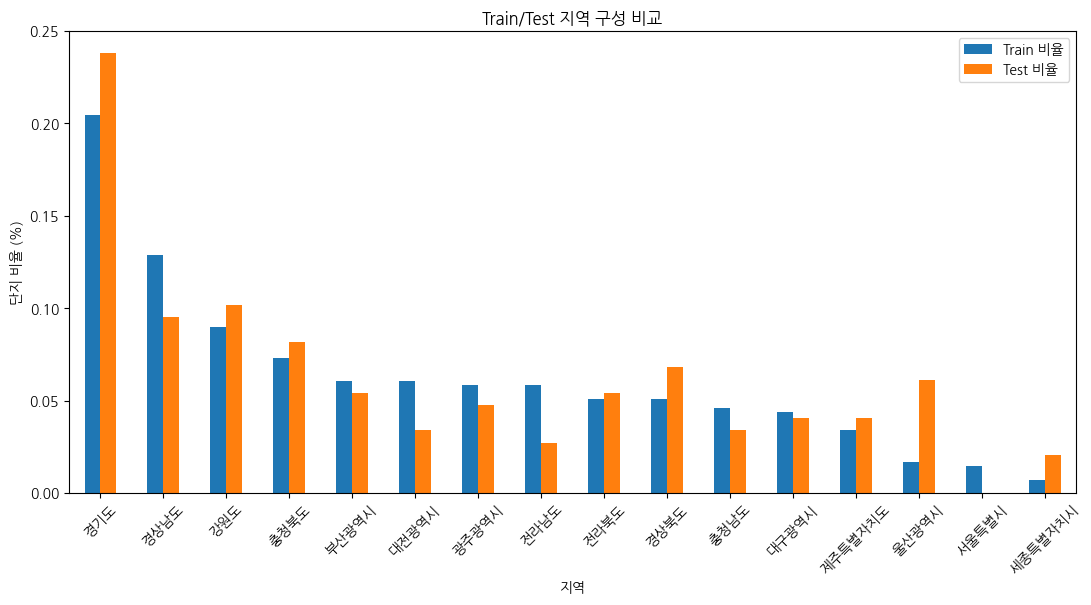

In [74]:
train_regions = set(train_dist['지역'])
test_regions = set(test_dist['지역'])

print('Train에만 있는 지역:', train_regions - test_regions)
print('Test에만 있는 지역:', test_regions - train_regions)

region_compare[
    ['Train 비율', 'Test 비율']
].plot(
    kind='bar',
    figsize=(13, 6)
)

plt.xlabel('지역')
plt.ylabel('단지 비율 (%)')
plt.title('Train/Test 지역 구성 비교')
plt.xticks(rotation=45)
plt.legend()

plt.show()

**Train/Test 지역 구성 비교 결과**

- Train과 Test에는 대부분 동일한 지역이 포함되어 있으나 지역별 단지 비중에는 일부 차이가 나타났다.
- Test에서는 울산광역시와 경기도의 비중이 Train보다 각각 약 4.4%p, 3.4%p 높게 나타났다.
- 반대로 경상남도, 전라남도, 대전광역시는 Test에서의 비중이 각각 약 3.4%p, 3.1%p, 2.7%p 낮았다.
- 서울특별시는 Train에는 포함되어 있으나 Test에는 존재하지 않았으며,
  Test에만 새롭게 등장하는 지역은 없었다.
- 따라서 주요 수치형 변수의 분포는 전반적으로 유사하지만,
  지역 구성에는 일정 수준의 Distribution Shift가 존재하는 것으로 확인되었다.
- 지역은 앞선 EDA에서 세대당 등록차량수와 관련된 정보를 포함하는 것으로 나타났으므로,
  지역 비중 차이가 Test 예측 성능에 영향을 줄 가능성을 고려할 필요가 있다.

## 7. EDA 종합 결과

- 단지내주차면수는 등록차량수와 가장 강한 관계를 보였으며(Spearman 0.870),
  단지 규모를 제거한 이후에도 주차 공급 수준과 차량 보유 수준의 관계가 확인되었다.
- 평균 전용면적은 세대당 등록차량수와 비교적 강한 양의 관계를 보였고(Spearman 0.689),
  임대보증금·임대료 역시 중간 정도의 양의 관계를 나타냈다.
- 공급유형과 자격유형에 따라 세대당 차량 보유 수준에 뚜렷한 차이가 나타났다.
- 지역 인구구조에서는 20-50대 비율보다 30-50대 비율이 세대당 차량수와 더 높은 관계를 보였다.
- Train/Test의 주요 수치형 변수 분포는 전반적으로 유사했으나 지역 구성에는 일부 차이가 확인되었다.

이상의 EDA 결과를 바탕으로 단지별 행을 세대수 가중 방식으로 집계하고,
주택 구성·공급유형·자격유형·지역 특성을 반영한 피처를 생성한다.

#전처리

## 1. 행 단위 전처리

**발견된 문제와 처리 방침**

| 문제 | 원인 추정 | 처리 |
|---|---|---|
| `임대보증금`·`임대료`가 문자형이며 `-` 포함 | 금액 정보가 없는 평형(주로 상가, 일부 공공임대) | `-` → 결측 → 숫자 변환. 집계 시 결측은 제외 |
| `지하철역수`·`버스정류장수` 결측 | 조사되지 않았거나 주변에 없음 | 0으로 대체 ("도보 10분 내 없음"으로 간주) |
| test `자격유형` 결측 | 입력 누락 | 같은 단지의 최빈 자격유형으로 대체 |
| 상가 행 혼재 | 단지 내 상가 | 주거 피처 계산에서 제외, 상가 수는 별도 피처로 보존 |
| 공급유형 세분화(공공임대 5/10/50년, 분납 등) | 정책 유형 차이 | 비율 피처 + 공공임대 세부유형 피처로 반영 |

### 1-1. 임대보증금·임대료: 문자 → 숫자

`-`는 "값 없음"이므로 0이 아니라 결측으로 처리.

In [75]:
train_c = eda_train.copy()
test_c = eda_test_eval.copy()

print('[처리 후] dtype:', train_c[['임대보증금', '임대료']].dtypes.to_dict(), '| 결측:', train_c[['임대보증금', '임대료']].isna().sum().to_dict())
print('\n[처리 후 결측 행의 건물구분 분포]'); display(train_c.loc[train_c['임대보증금'].isna(), '임대건물구분'].value_counts())
display(train_c[['임대보증금', '임대료']].describe().T.round(0))

[처리 후] dtype: {'임대보증금': dtype('float64'), '임대료': dtype('float64')} | 결측: {'임대보증금': 581, '임대료': 584}

[처리 후 결측 행의 건물구분 분포]


,count
임대건물구분,
상가,562
아파트,19


,count,mean,std,min,25%,50%,75%,max
임대보증금,2288.0,25871650.0,19557754.0,3056000.0,14404000.0,20434500.0,31959250.0,213863000.0
임대료,2285.0,191086.0,125503.0,16650.0,110530.0,159960.0,232200.0,1058030.0


### 1-2. 지하철역수, 버스정류장수: 결측 → 0

결측 단지 대부분이 지방·외곽 단지일 가능성이 높고, 교통 피처는 "접근성이 있다/없다"의 의미가 크므로 0으로

In [76]:
TRANSIT = ['지하철역수', '버스정류장수']
print('[처리 전 결측 — 단지 수 기준]')
display(pd.DataFrame({'train': train_c.groupby('단지코드')[TRANSIT].first().isna().sum(),
                      'test':  test_c.groupby('단지코드')[TRANSIT].first().isna().sum()}))
miss_regions = train_c.loc[train_c['지하철역수'].isna(), '지역'].value_counts()
print('[지하철역수 결측 행의 지역]'); display(miss_regions.to_frame('행 수'))

for d in (train_c, test_c):
    d[TRANSIT] = d[TRANSIT].fillna(0)

print('[처리 후 결측]', train_c[TRANSIT].isna().sum().to_dict(), test_c[TRANSIT].isna().sum().to_dict())
display(train_c.groupby('단지코드')[TRANSIT].first().describe().T.round(2))

[처리 전 결측 — 단지 수 기준]


,train,test
지하철역수,19,4
버스정류장수,0,0


[지하철역수 결측 행의 지역]


,행 수
지역,
충청남도,114
대전광역시,93


[처리 후 결측] {'지하철역수': 0, '버스정류장수': 0} {'지하철역수': 0, '버스정류장수': 0}


,count,mean,std,min,25%,50%,75%,max
지하철역수,411.0,0.12,0.38,0.0,0.0,0.0,0.0,3.0
버스정류장수,411.0,3.71,2.84,0.0,2.0,3.0,4.0,20.0


### 1-3. 자격유형 결측 (test)

같은 단지는 입주 자격 체계가 유사하므로 같은 단지의 최빈 자격유형으로 채움. 단지 전체가 결측이면 가장 흔한 A로 채우기.

In [77]:
miss_rows = test_c[test_c['자격유형'].isna()]
print('[처리 전] 결측 행'); display(miss_rows[['단지코드', '공급유형', '전용면적', '전용면적별세대수', '자격유형']])
for c in miss_rows['단지코드'].unique():
    print(f'단지 {c} 의 자격유형 분포:', test_c.loc[test_c['단지코드'] == c, '자격유형'].value_counts(dropna=False).to_dict())

def fill_qual(df):
    df = df.copy()
    df['자격유형'] = df.groupby('단지코드')['자격유형'].transform(
        lambda s: s.fillna(s.mode().iloc[0] if s.notna().any() else 'A'))
    return df

train_c, test_c = fill_qual(train_c), fill_qual(test_c)
print('\n[처리 후] 해당 행'); display(test_c.loc[miss_rows.index, ['단지코드', '공급유형', '자격유형']])
print('자격유형 결측:', train_c['자격유형'].isna().sum(), test_c['자격유형'].isna().sum())

[처리 전] 결측 행


,단지코드,공급유형,전용면적,전용면적별세대수,자격유형
196,C2411,국민임대,46.90,240,NaN
258,C2253,영구임대,26.37,745,NaN


단지 C2411 의 자격유형 분포: {'A': 4, nan: 1}
단지 C2253 의 자격유형 분포: {'D': 28, 'C': 2, nan: 1}

[처리 후] 해당 행


,단지코드,공급유형,자격유형
196,C2411,국민임대,A
258,C2253,영구임대,D


자격유형 결측: 0 0


## 2. 단지 단위 집계 & 피처 생성

평형 단위 행을 **단지 1행**으로 요약. 단순히 첫 값이나 평균을 쓰지 않고, **주차수요에 영향을 줄 것이라는 가설**을 세우고 그에 맞게 피처를 설계.

| 그룹 | 가설 | 피처 |
|---|---|---|
| 5-1 규모 | 세대가 많을수록 차량이 많다 | 총세대수, 아파트세대수, 상가수, 공가비율 |
| 5-2 주차 공급 | 현재 공급량은 수요를 일부 반영한다 | 단지내주차면수, 세대당주차면수 |
| 5-3 면적 | 넓은 집일수록 가구원·소득이 많아 차량 보유가 많다 | 평균전용면적, 면적구간 비율 |
| 5-4 임대조건 | 보증금·임대료는 경제력의 대리 지표 | 평균임대보증금, 평균임대료 |
| 5-5 공급유형 | 정책 유형마다 입주 계층이 다르다 | 공급유형 비율, 공공임대 세부유형 비율 |
| 5-6 자격유형 | 입주 자격은 소득·가구 특성을 반영한다 | 주요 자격유형 비율 |
| 5-7 입지·지역 | 대중교통 접근성과 지역 인구구조가 차량 보유에 영향 | 지하철역수, 버스정류장수, 지역_20~50대 비율 |
| 6-1 상호작용 | 공공임대에서는 면적·규모 효과가 더 크다 | 공공x면적, 공공x세대수 |


- 주거 특성 피처(면적, 금액, 유형 비율)는 아파트 행만 사용. 상가의 면적,금액은 주거 수요와 무관.
- 평균은 세대수 가중 평균을 사용. (단순 평균 X)
- 비율 피처는 세대수 기준 비율.(행 수 기준 아님)

In [78]:
# 집계에 공통으로 쓰는 뼈대: 단지 속성 + 아파트 행 분리
def split_rows(df):
    base = df.groupby('단지코드', sort=False).agg(
        지역=('지역', 'first'), 총세대수=('총세대수', 'first'), 공가수=('공가수', 'first'),
        지하철역수=('지하철역수', 'first'), 버스정류장수=('버스정류장수', 'first'),
        단지내주차면수=('단지내주차면수', 'first'))
    if '등록차량수' in df:
        base['등록차량수'] = df.groupby('단지코드', sort=False)['등록차량수'].first()
    apt = df[df['임대건물구분'] == '아파트'].copy()
    return base, apt

base_tr, apt_tr = split_rows(train_c)
base_te, apt_te = split_rows(test_c)
print('단지 속성 뼈대:', base_tr.shape, base_te.shape)
print('아파트 행 / 전체 행:', f'{len(apt_tr)}/{len(train_c)} (train)', f'{len(apt_te)}/{len(test_c)} (test)')
print('아파트 행이 전혀 없는 단지:', sorted(set(base_tr.index) - set(apt_tr['단지코드'])), sorted(set(base_te.index) - set(apt_te['단지코드'])))

단지 속성 뼈대: (411, 7) (147, 6)
아파트 행 / 전체 행: 2307/2869 (train) 831/1008 (test)
아파트 행이 전혀 없는 단지: [] []


In [79]:
# 세대수 가중 평균 / 세대수 기준 비율 헬퍼
def wmean(g, col, w='전용면적별세대수'):
    m = g[col].notna() & (g[w] > 0)
    return np.average(g.loc[m, col], weights=g.loc[m, w]) if m.any() else np.nan

def share(apt, mask, denom):
    """조건(mask)에 해당하는 세대수 / 단지 아파트 세대수"""
    num = apt.loc[mask].groupby('단지코드')['전용면적별세대수'].sum()
    return (num.reindex(denom.index).fillna(0) / denom.replace(0, np.nan)).fillna(0)

### 2-1. 규모 피처
- **아파트세대수**: 평형별 세대수 합(주거 세대만). 총세대수와 다를 수 있어 둘 다 보존.
- **상가수**: 상가 행의 세대수 합. 주거 피처에서 제외한 상가 정보를 잃지 않기 위함.
- **공가비율**: 공가수 ÷ 총세대수. 빈집이 많으면 실제 거주 세대가 적어 차량도 적을 것이라는 가설.

In [80]:
def f_scale(base, df, apt):
    out = pd.DataFrame(index=base.index)
    out['총세대수'] = base['총세대수']
    out['아파트세대수'] = apt.groupby('단지코드')['전용면적별세대수'].sum().reindex(base.index).fillna(0)
    out['상가수'] = df[df['임대건물구분'] == '상가'].groupby('단지코드')['전용면적별세대수'].sum().reindex(base.index).fillna(0)
    out['공가비율'] = base['공가수'] / base['총세대수']
    return out

scale_tr, scale_te = f_scale(base_tr, train_c, apt_tr), f_scale(base_te, test_c, apt_te)
display(scale_tr.describe().T.round(3))
print('상가가 있는 단지:', (scale_tr['상가수'] > 0).sum(), '/', len(scale_tr))

,count,mean,std,min,25%,50%,75%,max
총세대수,411.0,722.348,407.850,26.0,447.500,632.000,922.000,2568.000
아파트세대수,411.0,715.533,408.765,26.0,438.000,624.000,917.500,2568.000
상가수,411.0,1.367,5.500,0.0,0.000,0.000,0.000,45.000
공가비율,411.0,0.023,0.022,0.0,0.008,0.018,0.032,0.175


상가가 있는 단지: 33 / 411


### 2-2. 주차 공급 피처
- **세대당주차면수**: 주차면수 ÷ 총세대수. 단지 규모를 제거한 공급 수준.

In [81]:
def f_parking(base):
    out = pd.DataFrame(index=base.index)
    out['단지내주차면수'] = base['단지내주차면수']
    out['세대당주차면수'] = base['단지내주차면수'] / base['총세대수'].clip(lower=1)
    return out

park_tr, park_te = f_parking(base_tr), f_parking(base_te)
display(park_tr.describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
단지내주차면수,411.0,581.676,360.181,13.000,317.500,515.000,776.000,1798.000
세대당주차면수,411.0,0.814,0.240,0.109,0.718,0.846,0.947,1.545


### 2-3. 면적 피처
- **평균전용면적**: 세대수 가중 평균.
- **면적구간 비율**: 평균만으로는 "작은 집과 큰 집이 섞인 단지"와 "중간 크기만 있는 단지"를 구분할 수 없어 분포 정보를 추가.
- 구간 기준(30/45/60)은 train 전용면적 분포의 주요 밀집 구간과 임대주택 공급 면적대(소형 원룸형, 30~40대, 국민주택 규모 이하 중형)를 고려해 정함.

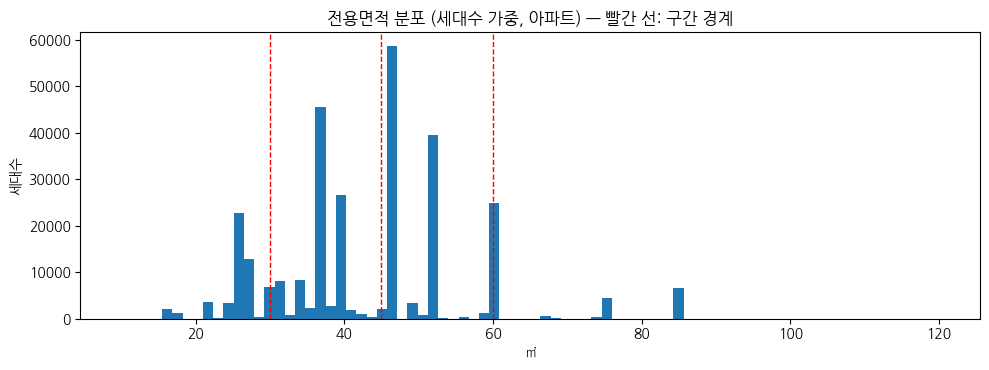

In [82]:
AREA_BINS = [(0, 30, '30미만'), (30, 45, '30_45'), (45, 60, '45_60'), (60, 999, '60이상')]

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.hist(apt_tr['전용면적'], bins=80, weights=apt_tr['전용면적별세대수'], range=(10, 120))
for b in [30, 45, 60]: ax.axvline(b, c='r', ls='--', lw=1)
ax.set_title('전용면적 분포 (세대수 가중, 아파트) — 빨간 선: 구간 경계'); ax.set_xlabel('㎡'); ax.set_ylabel('세대수')
plt.tight_layout(); plt.show()

In [83]:
def f_area(base, apt):
    out = pd.DataFrame(index=base.index)
    n_apt = apt.groupby('단지코드')['전용면적별세대수'].sum().reindex(base.index).fillna(0)
    out['평균전용면적'] = apt.groupby('단지코드').apply(lambda g: wmean(g, '전용면적')).reindex(base.index)
    for lo, hi, name in AREA_BINS:
        out[f'면적비율_{name}'] = share(apt, (apt['전용면적'] >= lo) & (apt['전용면적'] < hi), n_apt)
    return out

area_tr, area_te = f_area(base_tr, apt_tr), f_area(base_te, apt_te)

# 가중 vs 단순 평균 비교 — 가중 평균이 필요한 근거
simple = apt_tr.groupby('단지코드')['전용면적'].mean().reindex(base_tr.index)
diff = (simple - area_tr['평균전용면적']).abs()
print(f'단순평균과 가중평균 차이: 중앙값 {diff.median():.1f}㎡, 5㎡ 이상 차이 단지 {(diff >= 5).sum()}개')
display(area_tr.describe().T.round(3))
chk = area_tr[[c for c in area_tr if c.startswith('면적비율')]].sum(axis=1)
print('면적비율 합계 (아파트가 있는 단지는 1이어야 함):', chk[chk > 0].round(6).unique())

단순평균과 가중평균 차이: 중앙값 1.2㎡, 5㎡ 이상 차이 단지 11개


/tmp/ipykernel_1863/209746855.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out['평균전용면적'] = apt.groupby('단지코드').apply(lambda g: wmean(g, '전용면적')).reindex(base.index)
/tmp/ipykernel_1863/209746855.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out['평균전용면적'] = apt.groupby('단지코드').apply(lambda g: wmean(g, '전용면적')).reindex(base.index)


,count,mean,std,min,25%,50%,75%,max
평균전용면적,411.0,43.959,11.808,24.83,37.872,42.203,48.715,84.972
면적비율_30미만,411.0,0.149,0.253,0.00,0.000,0.000,0.227,1.000
면적비율_30_45,411.0,0.341,0.252,0.00,0.151,0.346,0.516,1.000
면적비율_45_60,411.0,0.460,0.342,0.00,0.196,0.425,0.717,1.000
면적비율_60이상,411.0,0.050,0.208,0.00,0.000,0.000,0.000,1.000


면적비율 합계 (아파트가 있는 단지는 1이어야 함): [1.]


### 2-4. 임대조건 피처
- **평균임대보증금, 평균임대료**: 세대수 가중 평균. 4-1에서 결측으로 바꾼 값은 평균 계산에서 제외.
- 모든 평형의 금액이 결측인 단지는 결측 처리.

In [84]:
def f_rent(base, apt):
    out = pd.DataFrame(index=base.index)
    g = apt.groupby('단지코드')
    out['평균임대보증금'] = g.apply(lambda x: wmean(x, '임대보증금')).reindex(base.index)
    out['평균임대료']   = g.apply(lambda x: wmean(x, '임대료')).reindex(base.index)
    return out

rent_tr, rent_te = f_rent(base_tr, apt_tr), f_rent(base_te, apt_te)
display(rent_tr.describe().T.round(0))
print('집계 후 결측 단지 수 — train:', rent_tr.isna().sum().to_dict(), '| test:', rent_te.isna().sum().to_dict())

/tmp/ipykernel_1863/4223185631.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out['평균임대보증금'] = g.apply(lambda x: wmean(x, '임대보증금')).reindex(base.index)
/tmp/ipykernel_1863/4223185631.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out['평균임대료']   = g.apply(lambda x: wmean(x, '임대료')).reindex(base.index)
/tmp/ipykernel_1863/4223185631.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the gr

,count,mean,std,min,25%,50%,75%,max
평균임대보증금,410.0,23546838.0,14982279.0,3056000.0,14347279.0,19639237.0,28652816.0,118682590.0
평균임대료,410.0,183740.0,114102.0,26805.0,113464.0,153923.0,213385.0,879891.0


집계 후 결측 단지 수 — train: {'평균임대보증금': 1, '평균임대료': 1} | test: {'평균임대보증금': 1, '평균임대료': 1}


### 2-5. 공급유형 피처
- **공급유형 비율 (4개)**: 국민임대 / 영구임대 / 행복주택 / 공공임대. 공공임대(5년, 10년, 50년, 분납 등)는 하나로 묶음.
- **공공임대 세부유형 비율**: 탐색 결과 10년 공공임대(세대당 약 1.45대)와 50년 공공임대(약 0.48대)의 수요가 크게 달라, 세부유형 비율을 따로 둠.
  - 공공10년: 10년,5년 공공임대, 공공분양 (분양전환형 성격)
  - 공공50년: 50년 공공임대 (영구임대 성격)
  - 공공분납, 장기전세
- 한 단지에 여러 유형이 섞일 수 있으므로 원-핫이 아니라 **세대수 비율**로 표현.

In [85]:
SUPPLY = ['국민임대', '영구임대', '행복주택', '공공임대']
SUB_TYPES = {'공공10년': '10년|5년|공공분양', '공공50년': '50년', '공공분납': '분납', '장기전세': '장기전세'}

def f_supply(base, apt):
    out = pd.DataFrame(index=base.index)
    n_apt = apt.groupby('단지코드')['전용면적별세대수'].sum().reindex(base.index).fillna(0)
    grp = apt['공급유형'].str.replace(r'공공임대.*', '공공임대', regex=True)
    for s in SUPPLY:
        out[f'공급_{s}'] = share(apt, grp == s, n_apt)
    for name, pat in SUB_TYPES.items():
        out[f'세부_{name}'] = share(apt, apt['공급유형'].str.contains(pat), n_apt)
    return out

sup_tr, sup_te = f_supply(base_tr, apt_tr), f_supply(base_te, apt_te)

print('[원본 공급유형 → 그룹 매핑 확인]')
m = train_c[train_c['임대건물구분'] == '아파트'][['공급유형']].drop_duplicates()
m['공급유형 그룹'] = m['공급유형'].str.replace(r'공공임대.*', '공공임대', regex=True)
m['세부유형'] = m['공급유형'].apply(lambda v: next((k for k, p in SUB_TYPES.items() if pd.Series([v]).str.contains(p)[0]), '-'))
display(m.sort_values('공급유형').reset_index(drop=True))

mixed = ((sup_tr[[f'공급_{s}' for s in SUPPLY]] > 0).sum(axis=1) > 1).sum()
print(f'2개 이상 공급유형이 섞인 단지: {mixed}개 → 비율 피처가 필요한 근거')
display(sup_tr.describe().T[['mean', 'max']].round(3))

[원본 공급유형 → 그룹 매핑 확인]


,공급유형,공급유형 그룹,세부유형
0,공공분양,공공분양,공공10년
1,공공임대(10년),공공임대,공공10년
2,공공임대(50년),공공임대,공공50년
3,공공임대(5년),공공임대,공공10년
4,공공임대(분납),공공임대,공공분납
5,국민임대,국민임대,-
6,영구임대,영구임대,-
7,장기전세,장기전세,장기전세
8,행복주택,행복주택,-


2개 이상 공급유형이 섞인 단지: 26개 → 비율 피처가 필요한 근거


,mean,max
공급_국민임대,0.731,1.000
공급_영구임대,0.091,1.000
공급_행복주택,0.069,1.000
공급_공공임대,0.107,1.000
세부_공공10년,0.083,1.000
세부_공공50년,0.023,1.000
세부_공공분납,0.002,0.740
세부_장기전세,0.001,0.316


### 2-6. 자격유형 피처
- 자격유형(A~N)은 입주 자격 체계로 소득, 가구 특성을 반영.
- 유형이 많고 일부는 매우 드물어 모두 쓰면 과적합 위험이 있으므로, **세대수 기준 상위 6개**만 비율 피처로 만들고 나머지는 암묵적으로 "기타"로 둠.

In [86]:
qual_cnt = train_c[train_c['임대건물구분'] == '아파트'].groupby('자격유형')['전용면적별세대수'].sum().sort_values(ascending=False)
display((qual_cnt / qual_cnt.sum()).round(3).to_frame('세대수 비중 (train)').T)

QUAL = ['A', 'C', 'H', 'J', 'E', 'I']
print('선택한 6개 유형의 누적 세대수 비중:', f'{qual_cnt[QUAL].sum() / qual_cnt.sum():.1%}')

def f_qual(base, apt):
    out = pd.DataFrame(index=base.index)
    n_apt = apt.groupby('단지코드')['전용면적별세대수'].sum().reindex(base.index).fillna(0)
    for q in QUAL:
        out[f'자격_{q}'] = share(apt, apt['자격유형'] == q, n_apt)
    return out

qual_tr, qual_te = f_qual(base_tr, apt_tr), f_qual(base_te, apt_te)
display(qual_tr.describe().T[['mean', 'max']].round(3))

자격유형,A,C,H,J,E,I,N,K,F,B,L,G,D,M,O
세대수 비중 (train),0.701,0.099,0.086,0.031,0.02,0.015,0.011,0.01,0.007,0.007,0.006,0.003,0.002,0.001,0.0


선택한 6개 유형의 누적 세대수 비중: 95.2%


,mean,max
자격_A,0.752,1.000
자격_C,0.077,1.000
자격_H,0.062,1.000
자격_J,0.038,1.000
자격_E,0.017,0.897
자격_I,0.010,0.433


### 2-7. 입지·지역 피처
- **지하철역수·버스정류장수**: 1-2에서 정리한 값을 그대로 사용.
- **지역_3050비율**: `age_gender_info`의 지역별 인구 비율 중 **30~50대(남녀 합)** 비율. 운전면허, 차량 보유가 활발한 연령층이 많은 지역일수록 차량 수요가 높을 것이라는 가설.
- 연령, 성별 컬럼을 모두 넣으면 지역이 16개뿐이라 사실상 지역 식별자가 되어 과적합 위험이 크므로, 가설에 맞는 **요약 지표 1개**만 사용.

In [87]:
age_cols_3050 = [
    c for c in age.columns
    if any(k in c for k in ['30대', '40대', '50대'])
]

print('30~50대 컬럼:', age_cols_3050)

age_feat = age[['지역']].copy()

age_feat['지역_3050비율'] = age[age_cols_3050].sum(axis=1)

display(
    age_feat
    .sort_values('지역_3050비율')
    .round(3)
    .T)


# 지역 누락 여부 확인
print(
    'train 지역 중 age 데이터에 없는 지역:',
    set(base_tr['지역']) - set(age_feat['지역']))

print(
    'test 지역 중 age 데이터에 없는 지역:',
    set(base_te['지역']) - set(age_feat['지역']))


# train/test에 지역 피처 붙이기
def f_location(base):
    out = base[['지역', '지하철역수', '버스정류장수']].copy()

    age_map = age_feat.set_index('지역')

    out['지역_3050비율'] = out['지역'].map(
        age_map['지역_3050비율'])

    return out


loc_tr = f_location(base_tr)
loc_te = f_location(base_te)

30~50대 컬럼: ['30대(여자)', '30대(남자)', '40대(여자)', '40대(남자)', '50대(여자)', '50대(남자)']


,14,8,4,10,9,5,1,0,12,11,2,7,13,6,3,15
지역,서울특별시,부산광역시,전라북도,울산광역시,제주특별자치도,강원도,경상남도,경상북도,전라남도,충청북도,대전광역시,충청남도,대구광역시,광주광역시,경기도,세종특별자치시
지역_3050비율,0.364,0.37,0.398,0.399,0.409,0.418,0.418,0.419,0.423,0.43,0.433,0.433,0.436,0.438,0.445,0.484


train 지역 중 age 데이터에 없는 지역: set()
test 지역 중 age 데이터에 없는 지역: set()


## 3. 집계 후 결측 처리

2-3, 2-4에서 **아파트 행이 없거나 모든 금액이 결측인 단지**는 평균전용면적, 평균임대보증금, 평균임대료가 결측.  
처리 방식: **같은 지역 단지의 중앙값 → 없으면 전체 중앙값**
- 지역마다 임대료 수준이 크게 달라 전체 중앙값보다 지역 중앙값이 현실적.
- 이상치 영향을 줄이기 위해 평균이 아닌 중앙값을 사용.
- 중앙값은 train+test 단지 전체에서 계산.

먼저 그룹별 피처를 하나로 합칩니다.

In [88]:
def assemble(base, *parts):
    df = pd.concat(parts, axis=1)
    if '등록차량수' in base: df['등록차량수'] = base['등록차량수']
    return df.reset_index()

tr = assemble(base_tr, loc_tr[['지역']], scale_tr, loc_tr[['지하철역수', '버스정류장수']], park_tr,
              area_tr, rent_tr, sup_tr, qual_tr, loc_tr[['지역_3050비율']])
te = assemble(base_te, loc_te[['지역']], scale_te, loc_te[['지하철역수', '버스정류장수']], park_te,
              area_te, rent_te, sup_te, qual_te, loc_te[['지역_3050비율']])
print(tr.shape, te.shape)

(411, 33) (147, 32)


In [89]:
FILL_COLS = ['평균전용면적', '평균임대보증금', '평균임대료']
print('[처리 전 결측 단지]')
display(pd.DataFrame({'train': tr[FILL_COLS].isna().sum(), 'test': te[FILL_COLS].isna().sum()}))
miss = pd.concat([tr.assign(set='train'), te.assign(set='test')])
miss = miss[miss[FILL_COLS].isna().any(axis=1)]
display(miss[['set', '단지코드', '지역', '총세대수', '아파트세대수', '상가수', '공급_공공임대', '세부_장기전세'] + FILL_COLS])

[처리 전 결측 단지]


,train,test
평균전용면적,0,0
평균임대보증금,1,1
평균임대료,1,1


,set,단지코드,지역,총세대수,아파트세대수,상가수,공급_공공임대,세부_장기전세,평균전용면적,평균임대보증금,평균임대료
348,train,C1326,부산광역시,1934,1934,0.0,0.0,0.0,31.974281,NaN,NaN
144,test,C2152,강원도,120,120,0.0,0.0,0.0,28.884500,NaN,NaN


In [90]:
full = pd.concat([tr, te], ignore_index=True)
fill_log = []
for c in FILL_COLS:
    reg_med = full.groupby('지역')[c].median(); glob_med = full[c].median()
    for name, d in [('train', tr), ('test', te)]:
        na = d[c].isna()
        d.loc[na, c] = d.loc[na, '지역'].map(reg_med)
        still = d[c].isna()
        d.loc[still, c] = glob_med
        fill_log.append({'컬럼': c, '데이터': name, '지역 중앙값 대체': int((na & ~still).sum()), '전체 중앙값 대체': int(still.sum())})
display(pd.DataFrame(fill_log))
print('[처리 후 결측]', tr[FILL_COLS].isna().sum().sum(), te[FILL_COLS].isna().sum().sum())

,컬럼,데이터,지역 중앙값 대체,전체 중앙값 대체
0,평균전용면적,train,0,0
1,평균전용면적,test,0,0
2,평균임대보증금,train,1,0
3,평균임대보증금,test,1,0
4,평균임대료,train,1,0
5,평균임대료,test,1,0


[처리 후 결측] 0 0


### 3-1. 상호작용 피처 (결측 처리 후 생성)
- **공공x면적** = 공공임대 비율 × 평균전용면적
- **공공x세대수** = 공공임대 비율 × 총세대수
- 근거: 공공임대(특히 10년)는 면적이 넓고 세대당 차량이 많아, 같은 면적·세대수 증가라도 차량 증가폭이 다른 유형보다 큼.
- 평균전용면적의 결측을 채운 뒤에 계산해야 결측이 전파되지 않으므로 이 위치에서 생성.

In [91]:
for d in (tr, te):
    d['공공x면적']  = d['공급_공공임대'] * d['평균전용면적']
    d['공공x세대수'] = d['공급_공공임대'] * d['총세대수']
display(tr[['공급_공공임대', '평균전용면적', '총세대수', '공공x면적', '공공x세대수']].describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
공급_공공임대,411.0,0.11,0.31,0.00,0.00,0.0,0.00,1.00
평균전용면적,411.0,43.96,11.81,24.83,37.87,42.2,48.71,84.97
총세대수,411.0,722.35,407.85,26.00,447.50,632.0,922.00,2568.00
공공x면적,411.0,6.93,20.57,0.00,0.00,0.0,0.00,84.97
공공x세대수,411.0,77.27,238.21,0.00,0.00,0.0,0.00,1444.00


# 모델링

In [92]:
train_c = eda_train.copy()
test_c = eda_test_eval.copy()

print('[처리 후] dtype:', train_c[['임대보증금', '임대료']].dtypes.to_dict(), '| 결측:', train_c[['임대보증금', '임대료']].isna().sum().to_dict())
print('\n[처리 후 결측 행의 건물구분 분포]'); display(train_c.loc[train_c['임대보증금'].isna(), '임대건물구분'].value_counts())
display(train_c[['임대보증금', '임대료']].describe().T.round(0))

[처리 후] dtype: {'임대보증금': dtype('float64'), '임대료': dtype('float64')} | 결측: {'임대보증금': 581, '임대료': 584}

[처리 후 결측 행의 건물구분 분포]


,count
임대건물구분,
상가,562
아파트,19


,count,mean,std,min,25%,50%,75%,max
임대보증금,2288.0,25871650.0,19557754.0,3056000.0,14404000.0,20434500.0,31959250.0,213863000.0
임대료,2285.0,191086.0,125503.0,16650.0,110530.0,159960.0,232200.0,1058030.0


## 1. 기존 전처리 결과 결합

In [93]:
rent_tr = f_rent(base_tr, apt_tr)
rent_te = f_rent(base_te, apt_te)

location_tr = base_tr[['지역', '지하철역수', '버스정류장수']].copy()
location_te = base_te[['지역', '지하철역수', '버스정류장수']].copy()

X_train = pd.concat(
    [scale_tr, park_tr, area_tr, rent_tr, location_tr],
    axis=1
)

X_test = pd.concat(
    [scale_te, park_te, area_te, rent_te, location_te],
    axis=1
)

y_train = base_tr['등록차량수'].astype(float)

X_train = X_train.loc[base_tr.index]
X_test = X_test.loc[base_te.index]
y_train = y_train.loc[base_tr.index]

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('Train 결측치 수:', X_train.isna().sum().sum())
print('Test 결측치 수:', X_test.isna().sum().sum())
display(X_train.head())

/tmp/ipykernel_1863/4223185631.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out['평균임대보증금'] = g.apply(lambda x: wmean(x, '임대보증금')).reindex(base.index)
/tmp/ipykernel_1863/4223185631.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out['평균임대료']   = g.apply(lambda x: wmean(x, '임대료')).reindex(base.index)
/tmp/ipykernel_1863/4223185631.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the gr

X_train: (411, 16)
X_test : (147, 16)
y_train: (411,)
Train 결측치 수: 2
Test 결측치 수: 2


,총세대수,아파트세대수,상가수,공가비율,단지내주차면수,세대당주차면수,평균전용면적,면적비율_30미만,면적비율_30_45,면적비율_45_60,면적비율_60이상,평균임대보증금,평균임대료,지역,지하철역수,버스정류장수
단지코드,,,,,,,,,,,,,,,,
C2515,545,545,0.0,0.031193,624.0,1.144954,40.260220,0.0,0.653211,0.346789,0.0,1.403597e+07,119431.266055,경상남도,0.0,3.0
C1407,1216,1216,0.0,0.010691,1285.0,1.056743,40.426875,0.0,0.618421,0.381579,0.0,2.760498e+07,171132.236842,대전광역시,1.0,1.0
C1945,755,755,0.0,0.007947,734.0,0.972185,50.280993,0.0,0.317881,0.682119,0.0,2.244915e+07,187414.211921,경기도,1.0,3.0
C1470,696,696,0.0,0.020115,645.0,0.926724,44.900690,0.0,0.364943,0.635057,0.0,1.939399e+07,125449.224138,전라북도,0.0,2.0
C1898,566,566,0.0,0.015901,517.0,0.913428,42.710318,0.0,0.478799,0.521201,0.0,1.757307e+07,119608.038869,전라북도,0.0,6.0


## 2. 5-fold CV

In [100]:
categorical_cols = ['지역']
numeric_cols = X_train.drop(columns=categorical_cols).columns.tolist()

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
])

In [101]:
linear_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', LinearRegression())
])

ridge_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', Ridge(alpha=10.0))
])

lasso_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', Lasso(alpha=1.0, max_iter=30000))
])

rf_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=500, max_features=0.8, min_samples_leaf=2,
        random_state=SEED, n_jobs=-1
    ))
])

gbm_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.03, max_depth=2,
        loss='huber', random_state=SEED
    ))
])

xgb_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', XGBRegressor(
        n_estimators=500, learning_rate=0.03, max_depth=3,
        subsample=0.8, colsample_bytree=0.8,
        objective='reg:squarederror', eval_metric='mae',
        random_state=SEED, n_jobs=-1
    ))
])

lgbm_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', LGBMRegressor(
        n_estimators=500, learning_rate=0.03, num_leaves=15,
        subsample=0.8, colsample_bytree=0.8,
        random_state=SEED, n_jobs=-1, verbosity=-1
    ))
])

cat_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', CatBoostRegressor(
        iterations=500, learning_rate=0.03, depth=5,
        loss_function='MAE', verbose=0,
        random_seed=SEED, allow_writing_files=False
    ))
])

SCORING = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2'
}

,Model,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_R2_mean
0,CatBoost,115.944,12.062,182.576,0.770
1,Lasso,121.593,13.719,176.927,0.783
2,XGBoost,122.714,16.820,188.233,0.757
3,Ridge,124.526,13.682,179.352,0.777
4,RandomForest,124.923,17.491,195.056,0.740
5,Linear,125.310,13.373,179.666,0.777
6,GradientBoosting,126.826,12.965,191.630,0.749
7,LightGBM,138.353,16.135,210.430,0.695


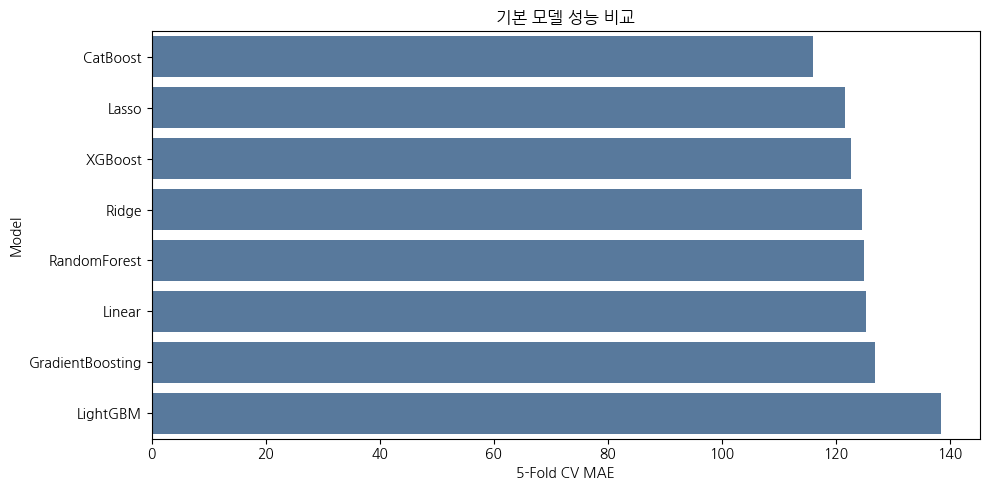

In [102]:
linear_cv = cross_validate(linear_pipe, X_train, y_train, cv=CV, scoring=SCORING, n_jobs=-1)
ridge_cv = cross_validate(ridge_pipe, X_train, y_train, cv=CV, scoring=SCORING, n_jobs=-1)
lasso_cv = cross_validate(lasso_pipe, X_train, y_train, cv=CV, scoring=SCORING, n_jobs=-1)
rf_cv = cross_validate(rf_pipe, X_train, y_train, cv=CV, scoring=SCORING, n_jobs=-1)
gbm_cv = cross_validate(gbm_pipe, X_train, y_train, cv=CV, scoring=SCORING, n_jobs=-1)
xgb_cv = cross_validate(xgb_pipe, X_train, y_train, cv=CV, scoring=SCORING, n_jobs=-1)
lgbm_cv = cross_validate(lgbm_pipe, X_train, y_train, cv=CV, scoring=SCORING, n_jobs=-1)
cat_cv = cross_validate(cat_pipe, X_train, y_train, cv=CV, scoring=SCORING, n_jobs=1)

cv_results = pd.DataFrame({
    'Model': ['Linear', 'Ridge', 'Lasso', 'RandomForest', 'GradientBoosting', 'XGBoost', 'LightGBM', 'CatBoost'],
    'CV_MAE_mean': [
        -linear_cv['test_mae'].mean(), -ridge_cv['test_mae'].mean(), -lasso_cv['test_mae'].mean(),
        -rf_cv['test_mae'].mean(), -gbm_cv['test_mae'].mean(), -xgb_cv['test_mae'].mean(),
        -lgbm_cv['test_mae'].mean(), -cat_cv['test_mae'].mean()
    ],
    'CV_MAE_std': [
        linear_cv['test_mae'].std(), ridge_cv['test_mae'].std(), lasso_cv['test_mae'].std(),
        rf_cv['test_mae'].std(), gbm_cv['test_mae'].std(), xgb_cv['test_mae'].std(),
        lgbm_cv['test_mae'].std(), cat_cv['test_mae'].std()
    ],
    'CV_RMSE_mean': [
        -linear_cv['test_rmse'].mean(), -ridge_cv['test_rmse'].mean(), -lasso_cv['test_rmse'].mean(),
        -rf_cv['test_rmse'].mean(), -gbm_cv['test_rmse'].mean(), -xgb_cv['test_rmse'].mean(),
        -lgbm_cv['test_rmse'].mean(), -cat_cv['test_rmse'].mean()
    ],
    'CV_R2_mean': [
        linear_cv['test_r2'].mean(), ridge_cv['test_r2'].mean(), lasso_cv['test_r2'].mean(),
        rf_cv['test_r2'].mean(), gbm_cv['test_r2'].mean(), xgb_cv['test_r2'].mean(),
        lgbm_cv['test_r2'].mean(), cat_cv['test_r2'].mean()
    ]
}).sort_values('CV_MAE_mean').reset_index(drop=True)

display(cv_results.round(3))

plt.figure(figsize=(10, 5))
sns.barplot(data=cv_results, x='CV_MAE_mean', y='Model', color='#4C78A8')
plt.xlabel('5-Fold CV MAE')
plt.ylabel('Model')
plt.title('기본 모델 성능 비교')
plt.tight_layout()
plt.show()

## 3. 하이퍼파라미터 튜닝

In [103]:
ridge_search = GridSearchCV(
    ridge_pipe,
    {'model__alpha': np.logspace(-3, 4, 20)},
    scoring='neg_mean_absolute_error', cv=CV, n_jobs=-1, refit=True
)
ridge_search.fit(X_train, y_train)

lasso_search = GridSearchCV(
    lasso_pipe,
    {'model__alpha': np.logspace(-3, 3, 20)},
    scoring='neg_mean_absolute_error', cv=CV, n_jobs=-1, refit=True
)
lasso_search.fit(X_train, y_train)

print('Ridge:', -ridge_search.best_score_, ridge_search.best_params_)
print('Lasso:', -lasso_search.best_score_, lasso_search.best_params_)

Ridge: 123.93868784171056 {'model__alpha': np.float64(4.832930238571752)}
Lasso: 121.21053337164912 {'model__alpha': np.float64(1.438449888287663)}


In [104]:
rf_params = {
    'model__n_estimators': [300, 500, 800, 1200],
    'model__max_depth': [None, 5, 8, 12, 16],
    'model__min_samples_split': [2, 4, 8, 12],
    'model__min_samples_leaf': [1, 2, 3, 5],
    'model__max_features': ['sqrt', 0.5, 0.8, 1.0]
}

rf_search = RandomizedSearchCV(
    rf_pipe, rf_params, n_iter=15,
    scoring='neg_mean_absolute_error', cv=CV,
    random_state=SEED, n_jobs=-1, refit=True, verbose=1
)
rf_search.fit(X_train, y_train)
print('RandomForest:', -rf_search.best_score_, rf_search.best_params_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
RandomForest: 122.99634346165149 {'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': None}


In [105]:
gbm_params = {
    'model__n_estimators': [150, 300, 500, 800],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.08],
    'model__max_depth': [1, 2, 3, 4],
    'model__min_samples_leaf': [1, 2, 4, 8],
    'model__subsample': [0.7, 0.85, 1.0],
    'model__loss': ['squared_error', 'huber']
}

gbm_search = RandomizedSearchCV(
    gbm_pipe, gbm_params, n_iter=15,
    scoring='neg_mean_absolute_error', cv=CV,
    random_state=SEED, n_jobs=-1, refit=True, verbose=1
)
gbm_search.fit(X_train, y_train)
print('GradientBoosting:', -gbm_search.best_score_, gbm_search.best_params_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
GradientBoosting: 121.3350307263438 {'model__subsample': 0.7, 'model__n_estimators': 500, 'model__min_samples_leaf': 8, 'model__max_depth': 3, 'model__loss': 'huber', 'model__learning_rate': 0.01}


In [106]:
xgb_params = {
    'model__n_estimators': [300, 500, 800, 1200],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.08],
    'model__max_depth': [2, 3, 4, 5],
    'model__min_child_weight': [1, 3, 5, 8],
    'model__subsample': [0.7, 0.85, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__reg_alpha': [0, 0.01, 0.1, 1],
    'model__reg_lambda': [1, 3, 5, 10]
}

xgb_search = RandomizedSearchCV(
    xgb_pipe, xgb_params, n_iter=15,
    scoring='neg_mean_absolute_error', cv=CV,
    random_state=SEED, n_jobs=-1, refit=True, verbose=1
)
xgb_search.fit(X_train, y_train)
print('XGBoost:', -xgb_search.best_score_, xgb_search.best_params_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
XGBoost: 121.77282334853717 {'model__subsample': 0.7, 'model__reg_lambda': 10, 'model__reg_alpha': 0.1, 'model__n_estimators': 800, 'model__min_child_weight': 1, 'model__max_depth': 5, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.6}


In [107]:
lgbm_params = {
    'model__n_estimators': [300, 500, 800, 1200],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.08],
    'model__num_leaves': [7, 15, 31, 63],
    'model__max_depth': [-1, 3, 5, 8],
    'model__min_child_samples': [5, 10, 20, 30],
    'model__subsample': [0.7, 0.85, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__reg_alpha': [0, 0.01, 0.1, 1],
    'model__reg_lambda': [0, 1, 3, 5]
}

lgbm_search = RandomizedSearchCV(
    lgbm_pipe, lgbm_params, n_iter=15,
    scoring='neg_mean_absolute_error', cv=CV,
    random_state=SEED, n_jobs=-1, refit=True, verbose=1
)
lgbm_search.fit(X_train, y_train)
print('LightGBM:', -lgbm_search.best_score_, lgbm_search.best_params_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
LightGBM: 126.61110262628384 {'model__subsample': 1.0, 'model__reg_lambda': 3, 'model__reg_alpha': 0.01, 'model__num_leaves': 31, 'model__n_estimators': 500, 'model__min_child_samples': 5, 'model__max_depth': 3, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.8}


In [108]:
cat_params = {
    'model__iterations': [300, 500, 800, 1200],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.08],
    'model__depth': [3, 4, 5, 6, 7],
    'model__l2_leaf_reg': [1, 3, 5, 10, 20],
    'model__random_strength': [0, 0.5, 1, 2]
}

cat_search = RandomizedSearchCV(
    cat_pipe, cat_params, n_iter=15,
    scoring='neg_mean_absolute_error', cv=CV,
    random_state=SEED, n_jobs=1, refit=True, verbose=1
)
cat_search.fit(X_train, y_train)
print('CatBoost:', -cat_search.best_score_, cat_search.best_params_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
CatBoost: 116.4946182387976 {'model__random_strength': 2, 'model__learning_rate': 0.01, 'model__l2_leaf_reg': 1, 'model__iterations': 800, 'model__depth': 6}


In [109]:
tuning_results = pd.DataFrame({
    'Model': ['Ridge', 'Lasso', 'RandomForest', 'GradientBoosting', 'XGBoost', 'LightGBM', 'CatBoost'],
    'Best_CV_MAE': [
        -ridge_search.best_score_, -lasso_search.best_score_, -rf_search.best_score_,
        -gbm_search.best_score_, -xgb_search.best_score_, -lgbm_search.best_score_,
        -cat_search.best_score_
    ],
    'Best_Params': [
        ridge_search.best_params_, lasso_search.best_params_, rf_search.best_params_,
        gbm_search.best_params_, xgb_search.best_params_, lgbm_search.best_params_,
        cat_search.best_params_
    ]
}).sort_values('Best_CV_MAE').reset_index(drop=True)

display(tuning_results)

best_name = tuning_results.loc[0, 'Model']
best_estimators = {
    'Ridge': ridge_search.best_estimator_,
    'Lasso': lasso_search.best_estimator_,
    'RandomForest': rf_search.best_estimator_,
    'GradientBoosting': gbm_search.best_estimator_,
    'XGBoost': xgb_search.best_estimator_,
    'LightGBM': lgbm_search.best_estimator_,
    'CatBoost': cat_search.best_estimator_
}

final_model = best_estimators[best_name]
print('최종 선택 모델:', best_name)
print('최종 CV MAE:', tuning_results.loc[0, 'Best_CV_MAE'])
print('최적 파라미터:', tuning_results.loc[0, 'Best_Params'])

,Model,Best_CV_MAE,Best_Params
0,CatBoost,116.494618,"{'model__random_strength': 2, 'model__learning..."
1,Lasso,121.210533,{'model__alpha': 1.438449888287663}
2,GradientBoosting,121.335031,"{'model__subsample': 0.7, 'model__n_estimators..."
3,XGBoost,121.772823,"{'model__subsample': 0.7, 'model__reg_lambda':..."
4,RandomForest,122.996343,"{'model__n_estimators': 500, 'model__min_sampl..."
5,Ridge,123.938688,{'model__alpha': 4.832930238571752}
6,LightGBM,126.611103,"{'model__subsample': 1.0, 'model__reg_lambda':..."


최종 선택 모델: CatBoost
최종 CV MAE: 116.4946182387976
최적 파라미터: {'model__random_strength': 2, 'model__learning_rate': 0.01, 'model__l2_leaf_reg': 1, 'model__iterations': 800, 'model__depth': 6}


## 4. 예측

In [110]:
final_model.fit(X_train, y_train)
test_prediction = np.clip(final_model.predict(X_test), 0, None)

test_result = pd.DataFrame({
    '단지코드': X_test.index,
    '예측등록차량수': test_prediction
})

print('예측 단지 수:', len(test_result))
display(test_result.head())

예측 단지 수: 147


,단지코드,예측등록차량수
0,C1072,802.944015
1,C1128,1219.806841
2,C1456,584.267985
3,C1840,529.990718
4,C1332,1149.176618


# 앙상블



## 1. 타깃 & 학습 가중치

In [112]:
tr['세대당등록차량수'] = tr['등록차량수'] / tr['총세대수']

drop_cols = ['단지코드', '등록차량수', '세대당등록차량수', '지역']
feature_cols = [c for c in tr.columns if c not in drop_cols]

X = tr[feature_cols].copy()
X = X.fillna(X.median(numeric_only=True))

y_ratio = tr['세대당등록차량수'].values
weight = tr['총세대수'].values
household = tr['총세대수'].values
y_true = tr['등록차량수'].values

## 2. 5-fold CV (선형회귀 + LightGBM, 세대수 가중치 반영)

In [113]:
oof_lr = np.zeros(len(tr))
oof_lgbm = np.zeros(len(tr))

for fold, (tr_idx, val_idx) in enumerate(CV.split(X), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr = y_ratio[tr_idx]
    w_tr = weight[tr_idx]

    lr = LinearRegression()
    lr.fit(X_tr, y_tr, sample_weight=w_tr)
    oof_lr[val_idx] = lr.predict(X_val)

    lgbm = LGBMRegressor(
        objective='mae',
        n_estimators=500,
        learning_rate=0.03,
        random_state=SEED,
        verbose=-1
    )

    lgbm.fit(X_tr, y_tr, sample_weight=w_tr)
    oof_lgbm[val_idx] = lgbm.predict(X_val)

    print(f'Fold {fold} 완료')

Fold 1 완료
Fold 2 완료
Fold 3 완료
Fold 4 완료
Fold 5 완료


## 3. 원래 스케일로 복원 + CV 성능 비교

In [114]:
pred_lr_real = np.clip(oof_lr, 0, None) * household
pred_lgbm_real = np.clip(oof_lgbm, 0, None) * household
pred_ensemble_real = 0.3 * pred_lr_real + 0.7 * pred_lgbm_real

print('선형회귀 단독 CV MAE :', mean_absolute_error(y_true, pred_lr_real))
print('LightGBM 단독 CV MAE:', mean_absolute_error(y_true, pred_lgbm_real))
print('앙상블 CV MAE       :', mean_absolute_error(y_true, pred_ensemble_real))

선형회귀 단독 CV MAE : 115.1104572796166
LightGBM 단독 CV MAE: 112.66437073181356
앙상블 CV MAE       : 109.39181577453097


## 4. 전체 train으로 재학습

In [115]:
final_lr = LinearRegression()
final_lr.fit(X, y_ratio, sample_weight=weight)

final_lgbm = LGBMRegressor(objective='mae', n_estimators=500, learning_rate=0.03, random_state=SEED, verbose=-1)
final_lgbm.fit(X, y_ratio, sample_weight=weight)

X_test = te[feature_cols].copy()
X_test = X_test.fillna(X.median(numeric_only=True))  # train 기준 중앙값으로 채움 (누수 방지)

test_household = te['총세대수'].values

pred_test_lr = np.clip(final_lr.predict(X_test), 0, None) * test_household
pred_test_lgbm = np.clip(final_lgbm.predict(X_test), 0, None) * test_household
pred_test_ensemble = 0.3 * pred_test_lr + 0.7 * pred_test_lgbm

# sample_submission 형식 그대로 채워서 저장 (오류 3개 단지도 포함됨)
# 컬럼명이 무엇이든 상관없이 첫 번째 컬럼=식별자, 두 번째 컬럼=예측값으로 처리
id_col = submission.columns[0]
target_col = submission.columns[1]

submission_out = submission.copy()
pred_map = dict(zip(te['단지코드'], pred_test_ensemble))
submission_out[target_col] = submission_out[id_col].map(pred_map)

save_path = f'{BASE_PATH}/submission_ensemble.csv'
submission_out.to_csv(save_path, index=False)

print('제출 파일 저장 완료:', save_path)
submission_out.head()

제출 파일 저장 완료: /content/drive/MyDrive/프로젝트 1/submission_ensemble.csv


,code,num
0,C1072,778.821355
1,C1128,1282.655134
2,C1456,528.547381
3,C1840,476.323623
4,C1332,1203.291638
